# Final 2D Bubble Notebook

## Introduction

This notebook carries out the **one-dimensional (1D) analysis** of the critical bubble and related observables for vacuum decay at finite charge/density. The workflow is:

1. **Setup and parameters** — Set the project path and model parameters (potential $V(\phi)$, chemical potential $\omega$, spatial dimension $d=3$ for the O(3)-symmetric bounce).
2. **Imports** — Load `Bubble_finder` (potential, bounce solver, observables) and plotting.
3. **Conventions** — Reference for charge $Q$, energy $E$, and densities $\rho_Q = Q/V$, $\rho_E = E/V$ (volume $V = \frac{4}{3}\pi r_{\max}^3$).
4. **Section 1: One-dimensional critical bubble** — Compute the O(3) bounce profile $\phi(r)$ at fixed $\omega$, then charge/energy and densities for the homogeneous configuration and for the bubble; finally the $\omega=0$ (zero-charge) bounce for both O(3) and O(4).

Each code cell is preceded by a short explanation of what it does. All formulas use the same conventions as `Bubble_finder` (e.g. $\Omega(\phi) = V(\phi) - \omega^2\phi^2$, energy with optional background subtraction).

### Project path and parameters

The next cell sets the project root (so that `Bubble_finder` and `Q_ball_finder` can be imported) and the model parameters: $\phi_0$, $V_1$, $V_2$ (false/true vacua of $V$), and $\omega$ (chemical potential).

In [1]:
# ============================================================================
# Project path and configuration
# ============================================================================

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Model parameters (same potential as in the 4D bounce notebook)
PHI0 = 1.999   # field value near the center of the bounce
V1 = 1.0       # false vacuum
V2 = 2.0       # true vacuum
OMEGA = 0.85    # chemical potential ω (can be changed)

print(f"Project root: {PROJECT_ROOT}")
print(f"Potential: false vacuum at φ={V1}, true vacuum at φ={V2}")
print(f"φ0 = {PHI0},  ω = {OMEGA}")

Project root: /home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/BubbleX
Potential: false vacuum at φ=1.0, true vacuum at φ=2.0
φ0 = 1.999,  ω = 0.85


### Which energy are we plotting?

- **E_M (Minkowski energy)** — Physical, conserved: use for microcanonical comparison (same Q, compare energies). Code: `compute_energy_minkowski_tau0_ghost_2d` (2D), `compute_energy_minkowski_1d_spherical` (1D).
- **F_ω (grand-canonical functional)** — F_ω = E_M − ω Q; relevant at fixed ω. Use for fixed-ω barrier / branch. Code: `compute_Fomega_1d_spherical` (1D), `compute_Fomega_tau0_ghost_2d` (2D). Do **not** label F_ω as "energy" in physical comparisons.
- **H_E (Euclidean)** — Used in Newton residuals; do **not** use for physical energy (wrong sign structure). Code: `compute_HE_euclidean_tau0_ghost_2d`. Legacy `compute_energy_tau0_ghost_2d` returns H_E (deprecated).

The observables dict from `compute_observables_tau0_ghost` contains `E` (= H_E), `E_M`, and `E_M_hom`. Use **E_M** for physical energy; use **E**/E_hom only as a Newton diagnostic.

**Why “same Q but higher energy” was misleading.** Comparisons that showed a bubble having the same charge as the homogeneous configuration but a different “energy” were partly due to mixing quantities: (i) **E_M** (Minkowski energy) is the conserved physical energy; (ii) **F_ω** = E_M − ω Q is the grand-canonical functional (what the 1D scan and many plots report as “E” or “ρ_E”); (iii) **H_E** is the Euclidean Hamiltonian-like density used in the Newton residual. If one compared F_ω or H_E between bubble and homogeneous instead of E_M, the sign and magnitude differ from the true microcanonical energy difference. For a meaningful “same Q, compare energies” use **E_M** (and ΔE_M = E_M − E_M,hom).

### Imports

This cell imports NumPy, Matplotlib, and the `Bubble_finder` modules (potential, 1D bounce solver, 2D solver, ansatz utilities). It also builds the potential $U(\rho)=V(\phi)$ for the 2D solver and sets LaTeX rendering for plots.

In [2]:
# ============================================================================
# Imports
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from Q_ball_finder.grid import build_grid, RadialTimeGrid

from Bubble_finder.potential_bubble import (
    V_phi, dV_dphi, d2V_dphi2, Omega_phi, dOmega_dphi, d2Omega_dphi2, vacua_of_Omega,
)
from Bubble_finder.bounce2d import Bubble2DSettings, Bubble2DSolver, make_potential_from_V, solve_rho0_for_omega
from Bubble_finder.bounce_1d import solve_bounce
from Bubble_finder.ansatz_bubble import (
    AnsatzParams, build_seed_bubble, compute_negative_mode_1d, compute_Dp_shooting_1d, bc_projector_y,
    make_q_ball_objects, make_bubble_profile_1d_from_solve_bounce, PotentialModel,
)
from Bubble_finder.ansatz_bubble import select_best_seed

# Potential U(ρ)=V(φ) for the 2D solver (requires PHI0, V1, V2 from previous cell)
U, dU, d2U = make_potential_from_V(V_phi, dV_dphi, d2V_dphi2, phi0=PHI0, v1=V1, v2=V2)

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}",
})
plt.rcParams["figure.figsize"] = (7, 4.8)

print("Imports completed.")

Imports completed.


## Conventions and Observables (reference)

Reference for the conventions and observables used in the rest of the notebook. All formulas are consistent with the code in `Bubble_finder.observables_2d` and with the 2D solver.

**Twisted boundary conditions.** Half-box $\tau \in [-\beta/2,\, 0]$ with twist closure at $\tau = -\beta/2$. **Rotated frame**: $y = r(\varphi_{\mathrm{rot}} - \rho_0)$, $\bar y = r(\bar\varphi_{\mathrm{rot}} - \rho_0)$; homogeneous background $y = \bar y = 0$.

**Charge $Q$ and density $q(r)$.** We use the same convention as the 1D code:
$$
q(\tau,r) = \frac{1}{2}\,\mathrm{Re}\bigl(\bar\varphi\,\partial_\tau\varphi - \varphi\,\partial_\tau\bar\varphi\bigr)\,, \qquad Q(\tau) = 4\pi\int_0^{r_{\max}}\!\! r^2\, q(\tau,r)\,\mathrm{d}r\,.
$$
At $\tau=0$ the solver has no grid point; we use **ghost reconstruction**: values just above and below $\tau=0$ are defined by the twist ($y_+ = \bar y|_0$, $y_- = y|_0$, etc.), then we form the midpoint and a central $\tau$-derivative. So **ground-truth** $Q$ and $E$ are those at $\tau=0$ from this ghost procedure (`compute_charge_tau0_ghost_2d`, `compute_energy_tau0_ghost_2d`). Optional background subtraction for charge only: $Q \to Q - Q_{\mathrm{hom}}$ with $Q_{\mathrm{hom}} = 4\pi\,\omega\,\rho_0^2\,r_{\max}^3/3$.

**Energy $E$ (canonical, no background subtraction).** $H_E = (\partial_\tau\varphi)(\partial_\tau\bar\varphi) - (\partial_r\varphi)(\partial_r\bar\varphi) - V(\varphi\bar\varphi)$; $E(\tau) = 4\pi\int_0^{r_{\max}}\!\! r^2\, H_E\,\mathrm{d}r$ at $\tau=0$ (ghost procedure, stored as `sol.E_tau0`). Homogeneous: $E_{\mathrm{hom}} = V_{\mathrm{space}}\,(-\omega^2\rho_0^2 - V(\rho_0^2))$; use ratio $E/E_{\mathrm{hom}}$ (`homogeneous_energy_2d` or targets).

**Why $\omega\cdot Q$ is not the energy.** For a homogeneous Q-ball, $E$ and $Q$ are related by the thermodynamic identity, but for an inhomogeneous configuration (e.g. the bubble) $E$ is given by the integral above; $\omega\cdot Q \neq E$. So we never set $E_{\mathrm{target}} = \omega\cdot Q_{\mathrm{target}}$.

**Densities and targets.** Volume $V = \frac{4}{3}\pi\,L_r^3$ with $L_r = r_{\max}$. Charge density $\rho_Q = Q/V$, energy density $\rho_E = E/V$. **Targets** ($Q_{\mathrm{target}}$, $E_{\mathrm{target}}$, $\rho_{Q,\mathrm{target}}$, $\rho_{E,\mathrm{target}}$) are computed by applying the *same* $\tau=0$ ghost observables to the homogeneous configuration ($y = \bar y = 0$) on the same grid (`compute_targets_tau0_ghost`). Use them for ratios $Q/Q_{\mathrm{target}}$, $E/E_{\mathrm{target}}$ in scans.

## 1. One-dimensional critical bubble

In this section we compute the **O(3)-symmetric one-dimensional critical bubble** $\phi_{\mathrm{cb}}(r)$ at fixed chemical potential $\omega$.

The radial equation for the bounce profile in $d$ spatial dimensions is
$$
\phi''(r) + \frac{d-1}{r}\,\phi'(r) = \frac{\partial \Omega(\phi)}{\partial \phi} \, ,
$$
with $d = 3$ and grand potential $\Omega(\phi) = V(\phi) - \omega^2 \phi^2$, so that $\partial\Omega/\partial\phi = V'(\phi) - 2\omega^2\phi$. The **energy** of a 1D profile is
$$
E[\phi] = 4\pi \int_0^{\infty} \mathrm{d}r\, r^2\left[\tfrac12 (\partial_r \phi)^2 + \Omega(\phi)\right] \,.
$$

We impose:
- regularity at the origin, $\phi'(0) = 0$, so that the solution is smooth at $r = 0$;
- approach to the false vacuum as $r \to \infty$, $\phi(r) \to \phi_\text{false}$.

We use a simple **overshoot/undershoot** algorithm with bisection in the initial value $\phi(0)$ to find the bounce profile $\{ r_{\mathrm{cb}},\, \phi_{\mathrm{cb}}(r) \}$, which will later be used as input for the 2D construction.

**Implementation:** we use `solve_bounce` from `Bubble_finder.bounce_1d`; the output arrays `r_bounce` and `phi_bounce` (or equivalents) define the radial profile of the 1D critical bubble.


**Parameters and grand potential.** This cell sets the 1D bounce parameters (radial grid, tolerance), finds the two vacua of $\Omega(\phi) = V(\phi) - \omega^2\phi^2$, and plots $\Omega(\phi)$.

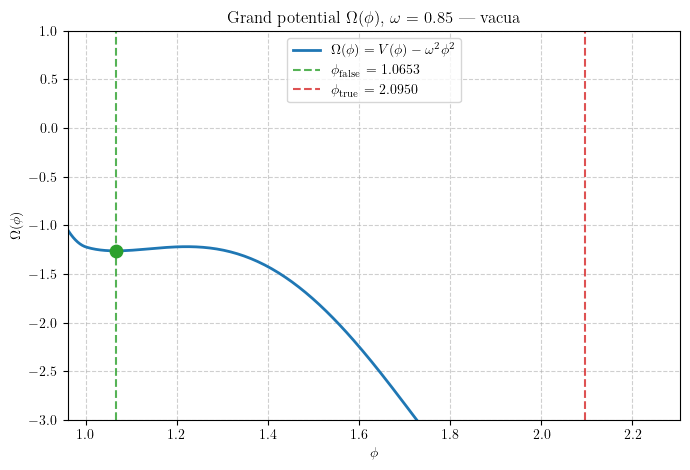

In [3]:
# ============================================================================
# 1D Bounce: parameters, vacua (grid), plot Ω(φ), solve (solve_bounce from bounce_1d)
# ============================================================================

# Parameters
PHI0_BOUNCE = PHI0
V1_BOUNCE = V1
V2_BOUNCE = V2
OMEGA_BOUNCE = OMEGA
D = 3
R0 = 1e-11
RMAX = 10.0
MAX_ITER = 100
VERBOSE = True

# Find vacua of Ω(φ) = V(φ) - ω²φ² using efficient grid method (two grids, then assign false/true by Ω)
phi_grid1 = np.linspace(max(0.5, V1_BOUNCE - 0.2), min(V2_BOUNCE - 0.1, V1_BOUNCE + 0.2), 500)
phi_grid2 = np.linspace(max(V1_BOUNCE + 0.1, V2_BOUNCE - 0.2), V2_BOUNCE+0.2, 500)
Omega_grid1 = np.array([Omega_phi(phi, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE) for phi in phi_grid1])
Omega_grid2 = np.array([Omega_phi(phi, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE) for phi in phi_grid2])
idx_min1 = np.argmin(Omega_grid1)
idx_min2 = np.argmin(Omega_grid2)
phi_near_v1 = phi_grid1[idx_min1]
phi_near_v2 = phi_grid2[idx_min2]
Omega_near_v1 = Omega_phi(phi_near_v1, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE)
Omega_near_v2 = Omega_phi(phi_near_v2, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE)
if Omega_near_v1 > Omega_near_v2:
    phi_false_grid, phi_true_grid = phi_near_v1, phi_near_v2
    Omega_false_grid, Omega_true_grid = Omega_near_v1, Omega_near_v2
else:
    phi_false_grid, phi_true_grid = phi_near_v2, phi_near_v1
    Omega_false_grid, Omega_true_grid = Omega_near_v2, Omega_near_v1

# Plot Ω(φ) and mark the two minima to verify they correspond to the vacua
# Free range: no clipping; extend below v1 and especially above v2
phi_plot = np.linspace(0.5, 3.0, 500)
Omega_plot = np.array([Omega_phi(phi, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE) for phi in phi_plot])
fig, ax = plt.subplots(figsize=(7, 4.8))
ax.plot(phi_plot, Omega_plot, lw=2, color="C0", label=r"$\Omega(\phi) = V(\phi) - \omega^2\phi^2$")
ax.axvline(phi_false_grid, color="C2", ls="--", lw=1.5, label=rf"$\phi_{{\mathrm{{false}}}}$ = {phi_false_grid:.4f}", alpha=0.8)
ax.axvline(phi_true_grid, color="C3", ls="--", lw=1.5, label=rf"$\phi_{{\mathrm{{true}}}}$ = {phi_true_grid:.4f}", alpha=0.8)
ax.scatter([phi_false_grid], [Omega_false_grid], color="C2", s=80, zorder=5)
ax.scatter([phi_true_grid], [Omega_true_grid], color="C3", s=80, zorder=5)
ax.set_xlabel(r"$\phi$")
ax.set_ylabel(r"$\Omega(\phi)$")
ax.set_xlim(phi_false_grid*0.9, phi_true_grid*1.1)
ax.set_ylim(-3, 1.0)
ax.set_title(rf"Grand potential $\Omega(\phi)$, $\omega$ = {OMEGA_BOUNCE:.2f} — vacua")
ax.legend()
ax.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

**Solve and plot.** This cell computes the thin-wall analytical action $S_0$, calls `solve_bounce` for the O(3) bounce at the chosen $\omega$, and plots the bounce profile $\phi(r)$.

Solving O(3) bounce solution...
Parameters: φ₀=1.999, v1=1.0, v2=2.0, ω=0.85
Analytical action (d=4, Q=0): S₀ = 80.590466
[vacua_of_Omega] ω=0.85
  phi_false=1.06503877578  Ω_false=-1.2608862793  dΩ=-5.29e-08  (ω²-W)=2.48e-08  Ω''=1.244e+01
  phi_true =2.09465574669  Ω_true =-4.54571225238  dΩ=-3.65e-07  (ω²-W)=8.71e-08  Ω''=4.175e+01
Vacua of Ω: phi_false=1.0650387758, phi_true=2.0946557467
  Iteration 0: Undershoot, φ(0)=1.579847, φ(∞)=1.123602, r_stop=1.4118
  Iteration 10: Undershoot, φ(0)=1.667827, φ(∞)=1.066543, r_stop=2.2136
  Iteration 20: Undershoot, φ(0)=1.668004, φ(∞)=1.065053, r_stop=3.3910
  Converged after 27 iterations: φ(0)=1.668005, φ(∞)=1.065041, φ'(∞)=2.711e-20

Bounce solution found:
  φ(0) = 1.668005
  φ(∞) ≈ 1.065041 (target false = 1.065039)
  r_max = 3.85
  Number of points: 1000
  phi range: [1.065041, 1.668005]


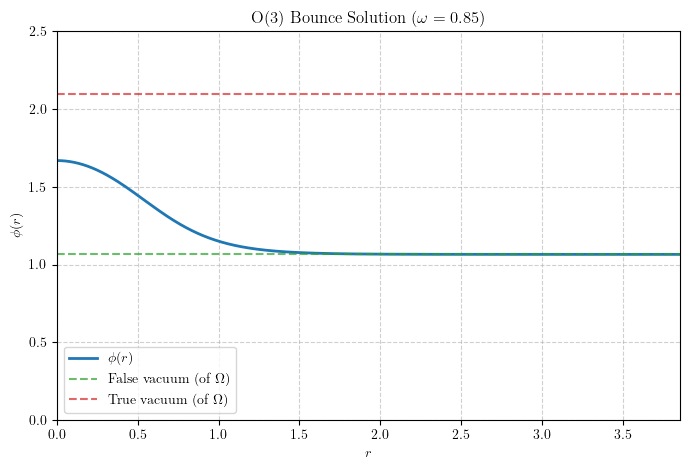

In [4]:
# Analytical Euclidean action for d=4, Q=0 (used for display only)
from scipy.special import spence
def S0_analytical(phi0):
    """S₀ = -π²/3 [φ₀ - 1 + Li₂((φ₀-1)/(φ₀-2))]; Li₂(z) = spence(1-z)."""
    term = (phi0 - 1) / (phi0 - 2)
    Li2_val = spence(1 - term)
    return -np.pi**2 / 3.0 * (phi0 - 1 + Li2_val)

# Solve bounce with chosen parameters
print("Solving O(3) bounce solution...")
print(f"Parameters: φ₀={PHI0_BOUNCE}, v1={V1_BOUNCE}, v2={V2_BOUNCE}, ω={OMEGA_BOUNCE}")
print(f"Analytical action (d=4, Q=0): S₀ = {S0_analytical(PHI0_BOUNCE):.6f}")
r_bounce, phi_bounce, phi0_bounce, phi_false_bounce, phi_true_bounce = solve_bounce(
    PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE, 
    d=D, r0=R0, rmax=RMAX, max_iter=MAX_ITER, verbose=VERBOSE
)

if r_bounce is not None:
    print(f"\nBounce solution found:")
    print(f"  φ(0) = {phi0_bounce:.6f}")
    print(f"  φ(∞) ≈ {phi_bounce[-1]:.6f} (target false = {phi_false_bounce:.6f})")
    print(f"  r_max = {r_bounce[-1]:.2f}")
    print(f"  Number of points: {len(r_bounce)}")
    print(f"  phi range: [{phi_bounce.min():.6f}, {phi_bounce.max():.6f}]")
    
    # Update phi_false and phi_true with analytical values
    phi_false = phi_false_grid
    phi_true = phi_true_grid
    
    # Plot bounce solution
    fig, ax = plt.subplots(figsize=(7, 4.8))
    ax.plot(r_bounce, phi_bounce, lw=2, color='C0', label=r"$\phi(r)$")
    ax.axhline(phi_false, color='C2', ls='--', lw=1.5, label=rf"False vacuum (of $\Omega$)", alpha=0.7)
    ax.axhline(phi_true, color='C3', ls='--', lw=1.5, label=rf"True vacuum (of $\Omega$)", alpha=0.7)
    ax.set_xlabel(r"$r$")
    ax.set_ylabel(r"$\phi(r)$")
    ax.set_xlim(0, r_bounce[-1])
    ax.set_ylim(0, phi_bounce.max()*1.5)
    ax.set_title(rf"O(3) Bounce Solution ($\omega = {OMEGA_BOUNCE:.2f}$)")
    ax.legend()
    ax.grid(True, ls="--", alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("Failed to find bounce solution.")

**Charge, energy and densities.** This cell computes total charge $Q$ and energy $E$, and the densities $Q/V$, $E/V$, for (i) the homogeneous configuration and (ii) the bubble configuration, using the volume $V = \frac{4}{3}\pi r_{\max}^3$ with $r_{\max}$ the maximum radius of the bounce.

In [5]:
# Charge, energy and densities (homogeneous vs bubble) — volume = (4/3)π r_max³ with r_max = bubble maximum radius
from Bubble_finder.observables_1d import (
    compute_charge, compute_Fomega_1d_spherical, compute_energy_minkowski_1d_spherical,
    Q_homogeneous_ball,
)

if r_bounce is not None:
    r_max = float(r_bounce[-1])
    V = (4.0 / 3.0) * np.pi * r_max**3

    # Homogeneous: E_M,hom = V·(ω² ρ0² + V(ρ0)),  F_ω,hom = V·Ω(ρ0)
    Q_hom = Q_homogeneous_ball(OMEGA_BOUNCE, phi_false_bounce, r_max)
    V_at_false = float(np.asarray(U(np.array([phi_false_bounce]))).flat[0])
    E_M_hom = V * (OMEGA_BOUNCE**2 * phi_false_bounce**2 + V_at_false)
    F_omega_hom = V * Omega_phi(phi_false_bounce, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE)
    rho_Q_hom = Q_hom / V
    rho_E_M_hom = E_M_hom / V
    rho_F_omega_hom = F_omega_hom / V

    # Bubble: E_M (Minkowski) and F_ω (grand-canonical)
    Q_bubble = compute_charge(r_bounce, phi_bounce, OMEGA_BOUNCE)
    E_M_bubble = compute_energy_minkowski_1d_spherical(r_bounce, phi_bounce, OMEGA_BOUNCE, U, R_ref=r_max)
    F_omega_bubble = compute_Fomega_1d_spherical(
        r_bounce, phi_bounce,
        PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE,
        phi_false_bounce, subtract_background=False
    )
    rho_Q_bubble = Q_bubble / V
    rho_E_M_bubble = E_M_bubble / V
    rho_F_omega_bubble = F_omega_bubble / V

    print("Volume (bubble maximum radius): V = (4/3)π r_max³")
    print(f"  r_max = {r_max:.4f}  →  V = {V:.6f}\n")
    print("Homogeneous (φ = φ_false):")
    print(f"  Q_hom = {Q_hom:.6f}   E_M,hom = {E_M_hom:.6f}   F_ω,hom = {F_omega_hom:.6f}")
    print(f"  Q_hom/V = {rho_Q_hom:.6f}   E_M,hom/V = {rho_E_M_hom:.6f}   F_ω,hom/V = {rho_F_omega_hom:.6f}\n")
    print("Bubble:")
    print(f"  Q_bubble = {Q_bubble:.6f}   E_M,bubble = {E_M_bubble:.6f}   F_ω,bubble = {F_omega_bubble:.6f}")
    print(f"  Q_bubble/V = {rho_Q_bubble:.6f}   E_M,bubble/V = {rho_E_M_bubble:.6f}   F_ω,bubble/V = {rho_F_omega_bubble:.6f}")
else:
    print("No bounce solution: charge/energy cannot be computed.")

Volume (bubble maximum radius): V = (4/3)π r_max³
  r_max = 3.8532  →  V = 239.637614

Homogeneous (φ = φ_false):
  Q_hom = 231.049350   E_M,hom = 90.628116   F_ω,hom = -302.155779
  Q_hom/V = 0.964161   E_M,hom/V = 0.378188   F_ω,hom/V = -1.260886

Bubble:
  Q_bubble = 233.708585   E_M,bubble = 96.465342   F_ω,bubble = -301.629170
  Q_bubble/V = 0.975258   E_M,bubble/V = 0.402547   F_ω,bubble/V = -1.258689


**Zero-charge bounce (ω = 0).** This cell solves and plots the bounce at $\omega=0$ for both O(3) and O(4) symmetry (the latter is the standard Coleman–De Luccia instanton in $d=4$).

Solving O(3) bounce for ω=0 (bubble_zero_charge)...
[vacua_of_Omega] ω=0
  phi_false=1.00000001839  Ω_false=-0.5  dΩ=1.67e-06  (ω²-W)=-8.35e-07  Ω''=9.636e+05
  phi_true =1.99986461045  Ω_true =-1.50000001833  dΩ=-4.20e-08  (ω²-W)=1.05e-08  Ω''=4.001e+00
Vacua of Ω: phi_false=1.0000000184, phi_true=1.9998646105
  Iteration 0: Undershoot, φ(0)=1.499932, φ(∞)=1.336373, r_stop=1.1604
  Iteration 10: Overshoot, φ(0)=1.995471, φ(∞)=1.000000, r_stop=2.5341
  Iteration 20: Undershoot, φ(0)=1.995052, φ(∞)=1.000242, r_stop=3.1309
  Converged after 27 iterations: φ(0)=1.995052, φ(∞)=1.000000, φ'(∞)=-2.497e-04
Solving O(4) bounce for ω=0...
[vacua_of_Omega] ω=0
  phi_false=1.00000001839  Ω_false=-0.5  dΩ=1.67e-06  (ω²-W)=-8.35e-07  Ω''=9.636e+05
  phi_true =1.99986461045  Ω_true =-1.50000001833  dΩ=-4.20e-08  (ω²-W)=1.05e-08  Ω''=4.001e+00
Vacua of Ω: phi_false=1.0000000184, phi_true=1.9998646105
  Iteration 0: Undershoot, φ(0)=1.499932, φ(∞)=1.347982, r_stop=1.3234
  Iteration 10: Overshoot, φ(0

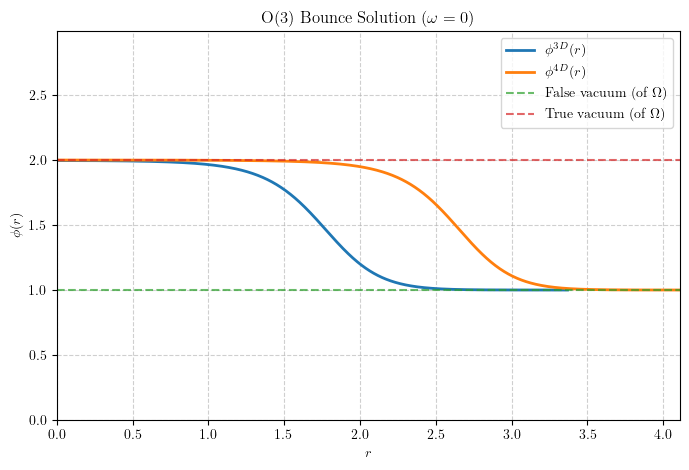

In [6]:
# Bounce for ω=0 (zero charge): same potential, omega=0 → Ω(φ)=V(φ)
print("Solving O(3) bounce for ω=0 (bubble_zero_charge)...")
r_bubble_zero_charge, phi_bubble_zero_charge, phi0_bzc, phi_false_bzc, phi_true_bzc = solve_bounce(
    PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, 0.0,
    d=D, r0=1e-6, rmax=RMAX, max_iter=MAX_ITER, verbose=VERBOSE
)

# O(4) bounce for ω=0 (same potential, d=4)
print("Solving O(4) bounce for ω=0...")
r_bubble_zero_d4, phi_bubble_zero_d4, phi0_bzc_d4, phi_false_bzc_d4, phi_true_bzc_d4 = solve_bounce(
    PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, 0.0,
    d=4, r0=1e-6, rmax=RMAX, max_iter=MAX_ITER, verbose=VERBOSE
)


if r_bubble_zero_charge is not None:
    print(f"  φ(0) = {phi0_bzc:.6f}, r_max = {r_bubble_zero_charge[-1]:.2f}, N = {len(r_bubble_zero_charge)}")
    fig, ax = plt.subplots(figsize=(7, 4.8))
    ax.plot(r_bubble_zero_charge, phi_bubble_zero_charge, lw=2, color="C0", label=r"$\phi^{3D}(r)$")
    ax.plot(r_bubble_zero_d4, phi_bubble_zero_d4, lw=2, color="C1", label=r"$\phi^{4D}(r)$")
    ax.axhline(phi_false_bzc, color="C2", ls="--", lw=1.5, label=rf"False vacuum (of $\Omega$)", alpha=0.7)
    ax.axhline(phi_true_bzc, color="C3", ls="--", lw=1.5, label=rf"True vacuum (of $\Omega$)", alpha=0.7)
    ax.set_xlabel(r"$r$")
    ax.set_ylabel(r"$\phi(r)$")
    ax.set_xlim(0, r_bubble_zero_d4[-1])
    ax.set_ylim(0, phi_bubble_zero_charge.max() * 1.5)
    ax.set_title(r"O(3) Bounce Solution ($\omega = 0$)")
    ax.legend()
    ax.grid(True, ls="--", alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("  Failed to find bounce for ω=0.")

**Omega scan.** The next cell finds the range of $\omega$ where $\Omega(\phi)$ has two minima and a barrier, then scans over $\omega$ and stores **total charge $Q$ and total energy $E$** (no background subtraction) for each converged bounce. Results are volume-corrected to a common $r_{\max}$ for comparison.

In [7]:
# ============================================================================
# Omega scan: total Q, F_ω (grand-canonical) and E_M (Minkowski energy). Volume-corrected to common r_max.
# ============================================================================

from Bubble_finder.observables_1d import compute_charge, compute_Fomega_1d_spherical, compute_energy_minkowski_1d_spherical

def has_barrier(phi0, v1, v2, omega, n_grid=400, barrier_tol=1e-6):
    """Return True if Ω(φ) has two distinct local minima separated by a barrier."""
    try:
        phi_false, phi_true = vacua_of_Omega(phi0, v1, v2, omega)
    except RuntimeError:
        return False
    if abs(phi_true - phi_false) < 1e-4:
        return False
    a, b = (phi_false, phi_true) if phi_false < phi_true else (phi_true, phi_false)
    Om_a = Omega_phi(a, phi0, v1, v2, omega)
    Om_b = Omega_phi(b, phi0, v1, v2, omega)
    grid = np.linspace(a, b, n_grid)
    Om = np.array([Omega_phi(x, phi0, v1, v2, omega) for x in grid])
    i_max = int(np.argmax(Om))
    if i_max == 0 or i_max == len(grid) - 1:
        return False
    Om_max = Om[i_max]
    if Om_max - max(Om_a, Om_b) <= barrier_tol:
        return False
    return True

# Scan parameters (single place)
phi0, v1, v2 = PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE
SCAN_RMAX = 1000.0
SCAN_MAX_ITER = 150
SCAN_N_POINTS = 100
SCAN_GRID_POINTS = 3000
SCAN_R0 = 1e-8

# Find ω_max where the barrier disappears
print("Finding maximum omega with a tunneling barrier...")
omega_test = np.linspace(0.0, 2.0, 400)
omega_lo, omega_hi = 0.0, None
for om in omega_test:
    if has_barrier(phi0, v1, v2, om):
        omega_lo = om
    else:
        omega_hi = om
        break
if omega_hi is None:
    omega_hi = omega_test[-1]
for _ in range(35):
    om_mid = 0.5 * (omega_lo + omega_hi)
    if has_barrier(phi0, v1, v2, om_mid):
        omega_lo = om_mid
    else:
        omega_hi = om_mid
omega_max = omega_lo
print(f"Omega range with tunneling barrier: [0, {omega_max:.6f}]")

# Scan: store total Q, F_ω (grand-canonical) and E_M (Minkowski energy)
print(f"\nScanning over omega in [0, {omega_max:.6f}]...")
print(f"Scan parameters: RMAX={SCAN_RMAX}, max_iter={SCAN_MAX_ITER}, n_points={SCAN_N_POINTS}, r0={SCAN_R0}")
n_omega = SCAN_N_POINTS
omega_scan = np.linspace(0.01, omega_max * 0.98, n_omega)
Q_vals = []
F_vals = []   # F_ω (grand-canonical functional)
E_vals = []   # E_M (Minkowski energy)
omega_valid = []
r_max_vals = []
phi_false_vals = []

for i, om in enumerate(omega_scan):
    if i % 10 == 0:
        print(f"  Processing omega = {om:.6f} ({i+1}/{n_omega})...")
    try:
        r_b, phi_b, phi0_b, phi_false_om, phi_true_om = solve_bounce(
            phi0, v1, v2, om,
            d=3, r0=SCAN_R0, rmax=SCAN_RMAX,
            max_iter=SCAN_MAX_ITER, verbose=False,
            n_grid_points=SCAN_GRID_POINTS
        )
        if r_b is not None and len(r_b) > 10:
            if (r_b[-1] - r_b[0]) <= 1e-12:
                if i % 10 == 0:
                    print(f"    r-range too small. Skipping omega = {om:.6f}")
                continue
            phi_end = phi_b[-1]
            dphi_dr = np.gradient(phi_b, r_b, edge_order=2)
            dphi_end = dphi_dr[-1]
            phi_error = abs(phi_end - phi_false_om)
            dphi_error = abs(dphi_end)
            if phi_error < 1e-3 and dphi_error < 1e-3:
                if len(r_b) < 50:
                    if i % 10 == 0:
                        print(f"    Solution has too few points ({len(r_b)}). Skipping.")
                    continue
                r_unique, idx_unique = np.unique(r_b, return_index=True)
                if len(r_unique) < len(r_b):
                    r_b = r_b[idx_unique]
                    phi_b = phi_b[idx_unique]
                # Total Q, F_ω (grand-canonical) and E_M (Minkowski energy)
                Q = compute_charge(r_b, phi_b, om)
                F_omega = compute_Fomega_1d_spherical(r_b, phi_b, phi0, v1, v2, om, phi_false_om, subtract_background=False)
                E_M = compute_energy_minkowski_1d_spherical(r_b, phi_b, om, U, R_ref=float(r_b[-1]))
                Q_vals.append(Q)
                F_vals.append(F_omega)
                E_vals.append(E_M)
                omega_valid.append(om)
                r_max_vals.append(r_b[-1])
                phi_false_vals.append(phi_false_om)
                if i % 10 == 0:
                    print(f"    Converged (φ error: {phi_error:.2e}, φ' error: {dphi_error:.2e})")
            else:
                if i % 10 == 0:
                    print(f"    Solution not converged (φ error: {phi_error:.2e}, φ' error: {dphi_error:.2e})")
        else:
            if i % 10 == 0:
                print(f"    No valid solution for omega = {om:.6f}")
    except (RuntimeError, ValueError) as e:
        if i % 10 == 0:
            print(f"    Error for omega = {om:.6f}: {str(e)[:50]}")

Q_vals = np.array(Q_vals)
F_vals = np.array(F_vals)
E_vals = np.array(E_vals)
omega_valid = np.array(omega_valid)
r_max_vals = np.array(r_max_vals)
phi_false_vals = np.array(phi_false_vals)

# Volume correction to common r_max_min so all points are comparable
r_max_min = r_max_vals.min()
V_min = (4.0 / 3.0) * np.pi * r_max_min**3
for i in range(len(omega_valid)):
    V_each = (4.0 / 3.0) * np.pi * r_max_vals[i]**3
    dV = V_min - V_each
    om_i = omega_valid[i]
    pf_i = phi_false_vals[i]
    # Total Q: add charge in shell (false vacuum)
    Q_vals[i] += om_i * pf_i**2 * dV
    Omega_false_i = Omega_phi(pf_i, phi0, v1, v2, om_i)
    # F_ω: add grand-canonical density Ω(φ_false) in shell
    F_vals[i] += Omega_false_i * dV
    # E_M: add Minkowski density ω² φ² + V(φ) = Ω(φ) + 2 ω² φ² in shell
    E_vals[i] += (Omega_false_i + 2.0 * om_i**2 * pf_i**2) * dV
print(f"Volume correction applied: r_max_min = {r_max_min:.4f}, common volume V_min = {V_min:.4f}")
print(f"\nScan complete: {len(omega_valid)} successful solutions. Q_vals, F_vals (F_ω), E_vals (E_M) are total (volume-corrected).")

Finding maximum omega with a tunneling barrier...
[vacua_of_Omega] ω=0
  phi_false=1.00000001839  Ω_false=-0.5  dΩ=1.67e-06  (ω²-W)=-8.35e-07  Ω''=9.636e+05
  phi_true =1.99986461045  Ω_true =-1.50000001833  dΩ=-4.20e-08  (ω²-W)=1.05e-08  Ω''=4.001e+00
[vacua_of_Omega] ω=0.00501253
  phi_false=1.00000065931  Ω_false=-0.500025125486  dΩ=2.22e-07  (ω²-W)=-1.11e-07  Ω''=1.161e+05
  phi_true =1.99989292233  Ω_true =-1.50010050797  dΩ=-1.89e-08  (ω²-W)=4.73e-09  Ω''=3.063e+00
[vacua_of_Omega] ω=0.0100251
  phi_false=1.00000284238  Ω_false=-0.500100502159  dΩ=-1.99e-08  (ω²-W)=9.96e-09  Ω''=6.679e+01
  phi_true =2.00021593785  Ω_true =-1.50040209755  dΩ=-1.18e-08  (ω²-W)=2.95e-09  Ω''=5.861e+00
[vacua_of_Omega] ω=0.0150376
  phi_false=1.00000672153  Ω_false=-0.500226130708  dΩ=-1.29e-07  (ω²-W)=6.44e-08  Ω''=6.328e+01
  phi_true =2.0002932091  Ω_true =-1.5009047355  dΩ=9.58e-09  (ω²-W)=-2.39e-09  Ω''=7.085e+00
[vacua_of_Omega] ω=0.0200501
  phi_false=1.00001240357  Ω_false=-0.500402012358  d

**Vacua and densities vs ω.** Below: (1) φ_false and φ_true of Ω(φ) as functions of ω; (2) charge density ρ_Q and energy density ρ_E for the bubble and for the homogeneous configuration vs ω.

[vacua_of_Omega] ω=0.01
  phi_false=1.00000282734  Ω_false=-0.500100000275  dΩ=-1.95e-08  (ω²-W)=9.76e-09  Ω''=6.682e+01
  phi_true =2.00021560335  Ω_true =-1.50040008959  dΩ=3.64e-08  (ω²-W)=-9.09e-09  Ω''=5.855e+00
[vacua_of_Omega] ω=0.0192519
  phi_false=1.00001137589  Ω_false=-0.500370639417  dΩ=-1.89e-08  (ω²-W)=9.46e-09  Ω''=6.116e+01
  phi_true =2.00036960727  Ω_true =-1.50148295192  dΩ=-2.56e-08  (ω²-W)=6.41e-09  Ω''=8.013e+00
[vacua_of_Omega] ω=0.0285038
  phi_false=1.00002628981  Ω_false=-0.500812486326  dΩ=-8.14e-08  (ω²-W)=4.07e-08  Ω''=5.780e+01
  phi_true =2.00056748844  Ω_true =-1.50325110698  dΩ=-6.41e-08  (ω²-W)=1.60e-08  Ω''=9.732e+00
[vacua_of_Omega] ω=0.0377557
  phi_false=1.0000480013  Ω_false=-0.501425557101  dΩ=-9.92e-08  (ω²-W)=4.96e-08  Ω''=5.538e+01
  phi_true =2.00080186027  Ω_true =-1.50570489379  dΩ=7.39e-09  (ω²-W)=-1.85e-09  Ω''=1.112e+01
[vacua_of_Omega] ω=0.0470076
  phi_false=1.0000768534  Ω_false=-0.502209875212  dΩ=-1.79e-07  (ω²-W)=8.97e-08  Ω''=5.3

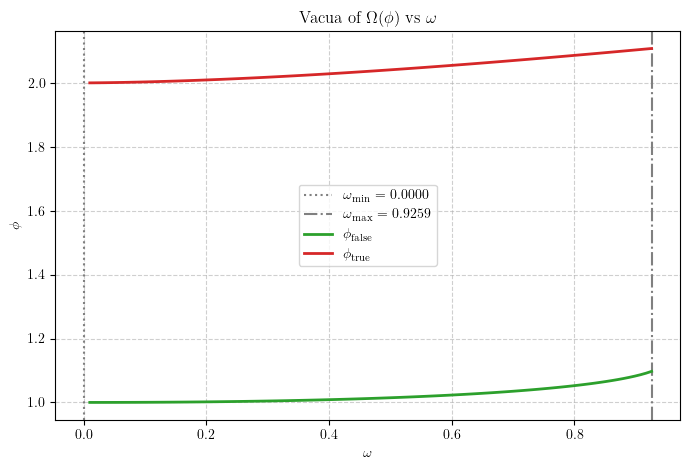

In [8]:
# φ_false and φ_true (minima of Ω(φ)) vs ω
phi_true_vals = np.array([vacua_of_Omega(phi0, v1, v2, om)[1] for om in omega_valid])
omega_min = 0
omega_max_val = omega_valid.max()

fig, ax = plt.subplots(figsize=(7, 4.8))
ax.axvline(omega_min, color="gray", ls=":", lw=1.5, label=rf"$\omega_{{\min}}$ = {omega_min:.4f}")
ax.axvline(omega_max_val, color="gray", ls="-.", lw=1.5, label=rf"$\omega_{{\max}}$ = {omega_max_val:.4f}")
ax.plot(omega_valid, phi_false_vals, lw=2, color="C2", label=r"$\phi_{\mathrm{false}}$")
ax.plot(omega_valid, phi_true_vals, lw=2, color="C3", label=r"$\phi_{\mathrm{true}}$")
ax.set_xlabel(r"$\omega$")
ax.set_ylabel(r"$\phi$")
ax.set_title(r"Vacua of $\Omega(\phi)$ vs $\omega$")
ax.legend()
ax.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

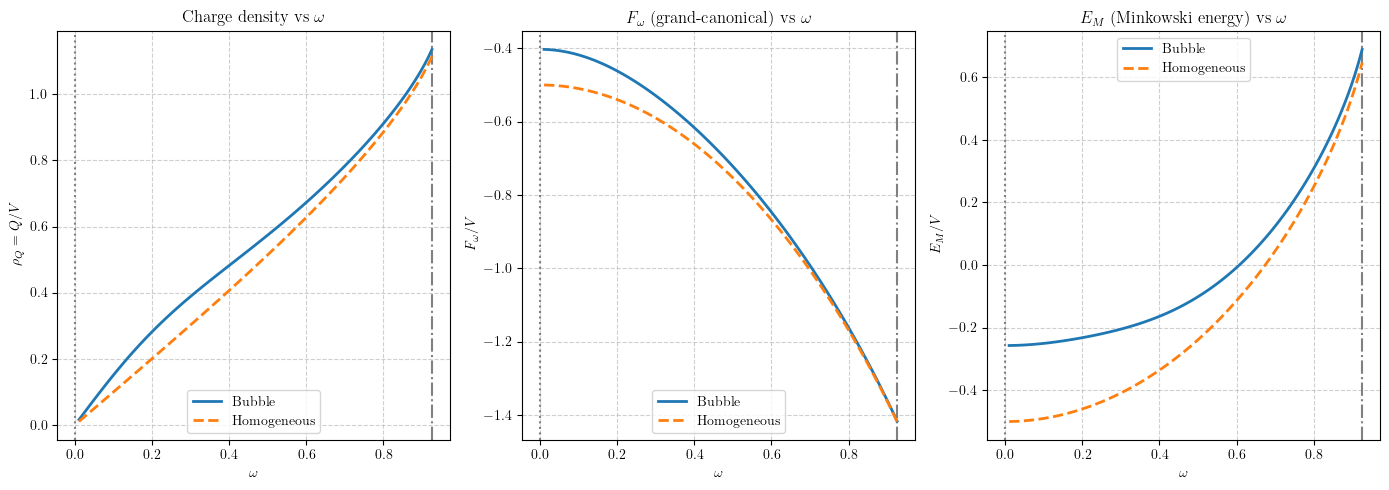

In [9]:
# Three panels: ρ_Q, F_ω/V and E_M/V (bubble vs homogeneous) vs ω
rho_Q_bubble = Q_vals / V_min
rho_F_bubble = F_vals / V_min
rho_E_bubble = E_vals / V_min
rho_Q_hom = omega_valid * phi_false_vals**2
rho_F_hom = np.array([Omega_phi(phi_false_vals[i], phi0, v1, v2, omega_valid[i]) for i in range(len(omega_valid))])
rho_E_hom = np.array([Omega_phi(phi_false_vals[i], phi0, v1, v2, omega_valid[i]) + 2.0 * omega_valid[i]**2 * phi_false_vals[i]**2 for i in range(len(omega_valid))])
omega_min = 0
omega_max_val = omega_valid.max()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))
ax1.axvline(omega_min, color="gray", ls=":", lw=1.5)
ax1.axvline(omega_max_val, color="gray", ls="-.", lw=1.5)
ax1.plot(omega_valid, rho_Q_bubble, lw=2, color="C0", label="Bubble")
ax1.plot(omega_valid, rho_Q_hom, lw=2, color="C1", ls="--", label="Homogeneous")
ax1.set_xlabel(r"$\omega$")
ax1.set_ylabel(r"$\rho_Q = Q/V$")
ax1.set_title(r"Charge density vs $\omega$")
ax1.legend()
ax1.grid(True, ls="--", alpha=0.6)

ax2.axvline(omega_min, color="gray", ls=":", lw=1.5)
ax2.axvline(omega_max_val, color="gray", ls="-.", lw=1.5)
ax2.plot(omega_valid, rho_F_bubble, lw=2, color="C0", label="Bubble")
ax2.plot(omega_valid, rho_F_hom, lw=2, color="C1", ls="--", label="Homogeneous")
ax2.set_xlabel(r"$\omega$")
ax2.set_ylabel(r"$F_\omega/V$")
ax2.set_title(r"$F_\omega$ (grand-canonical) vs $\omega$")
ax2.legend()
ax2.grid(True, ls="--", alpha=0.6)

ax3.axvline(omega_min, color="gray", ls=":", lw=1.5)
ax3.axvline(omega_max_val, color="gray", ls="-.", lw=1.5)
ax3.plot(omega_valid, rho_E_bubble, lw=2, color="C0", label="Bubble")
ax3.plot(omega_valid, rho_E_hom, lw=2, color="C1", ls="--", label="Homogeneous")
ax3.set_xlabel(r"$\omega$")
ax3.set_ylabel(r"$E_M/V$")
ax3.set_title(r"$E_M$ (Minkowski energy) vs $\omega$")
ax3.legend()
ax3.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

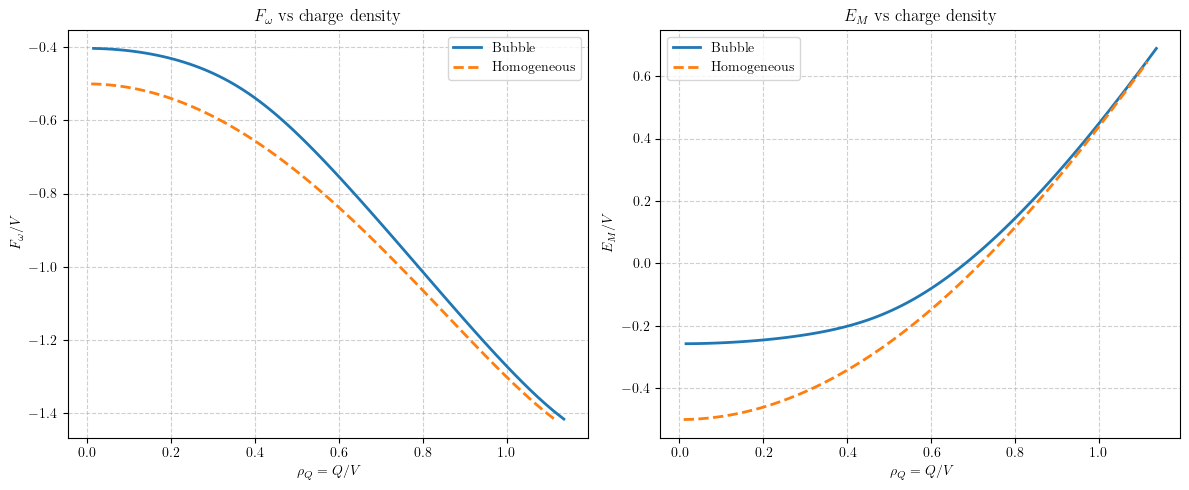

In [10]:
# F_ω/V and E_M/V vs charge density ρ_Q (bubble and homogeneous)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(rho_Q_bubble, rho_F_bubble, lw=2, color="C0", label="Bubble")
ax1.plot(rho_Q_hom, rho_F_hom, lw=2, color="C1", ls="--", label="Homogeneous")
ax1.set_xlabel(r"$\rho_Q = Q/V$")
ax1.set_ylabel(r"$F_\omega/V$")
ax1.set_title(r"$F_\omega$ vs charge density")
ax1.legend()
ax1.grid(True, ls="--", alpha=0.6)
ax2.plot(rho_Q_bubble, rho_E_bubble, lw=2, color="C0", label="Bubble")
ax2.plot(rho_Q_hom, rho_E_hom, lw=2, color="C1", ls="--", label="Homogeneous")
ax2.set_xlabel(r"$\rho_Q = Q/V$")
ax2.set_ylabel(r"$E_M/V$")
ax2.set_title(r"$E_M$ vs charge density")
ax2.legend()
ax2.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

**Matching ω.** Reference: **homogeneous configuration at $\omega = $ OMEGA** (from the project path cell: PHI0, V1, V2, OMEGA). Compute its charge density $\rho_Q^{\mathrm{ref}}$ and energy density $\rho_E^{\mathrm{ref}}$. Then find which $\omega$ in the scan gives a **bubble** with the same $\rho_Q$ as $\rho_Q^{\mathrm{ref}}$, and which $\omega$ gives a bubble with the same $\rho_E$ as $\rho_E^{\mathrm{ref}}$.

In [11]:
# Reference: homogeneous configuration at ω = OMEGA (from first cell: PHI0, V1, V2, OMEGA)
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar

phi_false_ref, _ = vacua_of_Omega(PHI0, V1, V2, OMEGA)
rho_Q_ref = OMEGA * phi_false_ref**2
rho_F_ref = Omega_phi(phi_false_ref, PHI0, V1, V2, OMEGA)  # F_ω/V for reference
rho_E_ref = Omega_phi(phi_false_ref, PHI0, V1, V2, OMEGA) + 2.0 * OMEGA**2 * phi_false_ref**2  # E_M/V for reference
print("Reference: homogeneous at ω = OMEGA (from project path cell)")
print(f"  OMEGA = {OMEGA},  φ_false = {phi_false_ref:.6f}")
print(f"  ρ_Q_ref = {rho_Q_ref:.6f},  ρ_Fω_ref = {rho_F_ref:.6f},  ρ_E_M_ref = {rho_E_ref:.6f}")
print()

# Interpolate bubble densities vs ω; find ω where bubble equals reference density
om_min, om_max = omega_valid.min(), omega_valid.max()
rho_Q_bubble_fn = interp1d(omega_valid, rho_Q_bubble, kind="linear", bounds_error=False, fill_value="extrapolate")
rho_F_bubble_fn = interp1d(omega_valid, rho_F_bubble, kind="linear", bounds_error=False, fill_value="extrapolate")
rho_E_bubble_fn = interp1d(omega_valid, rho_E_bubble, kind="linear", bounds_error=False, fill_value="extrapolate")
diff_Q = lambda om: rho_Q_bubble_fn(om) - rho_Q_ref
diff_F = lambda om: rho_F_bubble_fn(om) - rho_F_ref
diff_E = lambda om: rho_E_bubble_fn(om) - rho_E_ref

omega_same_rho_Q = None
omega_same_rho_E = None
omega_same_rho_F = None
if diff_Q(om_min) * diff_Q(om_max) <= 0:
    sol_Q = root_scalar(diff_Q, bracket=[om_min, om_max], method="brentq")
    omega_same_rho_Q = sol_Q.root
if diff_F(om_min) * diff_F(om_max) <= 0:
    sol_F = root_scalar(diff_F, bracket=[om_min, om_max], method="brentq")
    omega_same_rho_F = sol_F.root
if diff_E(om_min) * diff_E(om_max) <= 0:
    sol_E = root_scalar(diff_E, bracket=[om_min, om_max], method="brentq")
    omega_same_rho_E = sol_E.root

print("Bubble with same density as reference homogeneous:")
if omega_same_rho_Q is not None:
    rho_F_bubble_same_Q = float(rho_F_bubble_fn(omega_same_rho_Q))
    rho_E_bubble_same_Q = float(rho_E_bubble_fn(omega_same_rho_Q))
    delta_rho_F_same_Q = rho_F_bubble_same_Q - rho_F_ref
    delta_rho_E_same_Q = rho_E_bubble_same_Q - rho_E_ref
    F_bubble_same_Q = rho_F_bubble_same_Q * V_min
    E_bubble_same_Q = rho_E_bubble_same_Q * V_min
    F_hom_ref = rho_F_ref * V_min
    E_hom_ref = rho_E_ref * V_min
    delta_F_same_Q = F_bubble_same_Q - F_hom_ref
    delta_E_same_Q = E_bubble_same_Q - E_hom_ref
    print(f"  Same ρ_Q as ref:  ω = {omega_same_rho_Q:.6f}  (ρ_Q = {rho_Q_ref:.6f})")
    print(f"    ρ_Fω,bubble = {rho_F_bubble_same_Q:.6f},  Δρ_Fω = {delta_rho_F_same_Q:.6f}")
    print(f"    ρ_E_M,bubble = {rho_E_bubble_same_Q:.6f},  Δρ_E_M = {delta_rho_E_same_Q:.6f}")
    print(f"    F_ω,bubble = {F_bubble_same_Q:.6f},  F_ω,hom = {F_hom_ref:.6f},  ΔF_ω = {delta_F_same_Q:.6f}")
    print(f"    E_M,bubble = {E_bubble_same_Q:.6f},  E_M,hom = {E_hom_ref:.6f},  ΔE_M = {delta_E_same_Q:.6f}")
else:
    print("  Same ρ_Q: no solution in scan range.")
if omega_same_rho_F is not None:
    print(f"  Same ρ_Fω as ref:  ω = {omega_same_rho_F:.6f}  (ρ_Fω = {rho_F_ref:.6f})")
else:
    print("  Same ρ_Fω: no solution in scan range.")
if omega_same_rho_E is not None:
    print(f"  Same ρ_E_M as ref:  ω = {omega_same_rho_E:.6f}  (ρ_E_M = {rho_E_ref:.6f})")
else:
    print("  Same ρ_E_M: no solution in scan range.")

[vacua_of_Omega] ω=0.85
  phi_false=1.06503877578  Ω_false=-1.2608862793  dΩ=-5.29e-08  (ω²-W)=2.48e-08  Ω''=1.244e+01
  phi_true =2.09465574669  Ω_true =-4.54571225238  dΩ=-3.65e-07  (ω²-W)=8.71e-08  Ω''=4.175e+01
Reference: homogeneous at ω = OMEGA (from project path cell)
  OMEGA = 0.85,  φ_false = 1.065039
  ρ_Q_ref = 0.964161,  ρ_Fω_ref = -1.260886,  ρ_E_M_ref = 0.378188

Bubble with same density as reference homogeneous:
  Same ρ_Q as ref:  ω = 0.835507  (ρ_Q = 0.964161)
    ρ_Fω,bubble = -1.228117,  Δρ_Fω = 0.032770
    ρ_E_M,bubble = 0.390844,  Δρ_E_M = 0.012656
    F_ω,bubble = -143.136497,  F_ω,hom = -146.955771,  ΔF_ω = 3.819274
    E_M,bubble = 45.552724,  E_M,hom = 44.077677,  ΔE_M = 1.475047
  Same ρ_Fω as ref:  ω = 0.852282  (ρ_Fω = -1.260886)
  Same ρ_E_M as ref:  ω = 0.830398  (ρ_E_M = 0.378188)


## 2. 2D analysis

In this section we build the **2D Euclidean (τ, r) setup** and the **homogeneous ansatz** (constant field $y = \bar y = 0$, i.e. $\rho = \rho_0$ everywhere). We plot this ansatz in a single panel, then pass it to **Newton**; the solver converges to the 2D solution (which for the homogeneous initial guess remains homogeneous). We then plot the Newton solution.

The chemical potential $\omega$ used in the 2D solver can be chosen among:
- **OMEGA** — reference value from the project path cell;
- **omega_same_rho_Q** — $\omega$ at which the 1D bubble has the same charge density as the reference homogeneous configuration;
- **omega_same_rho_E** — $\omega$ at which the 1D bubble has the same energy density as the reference homogeneous configuration.

This allows one to compare 2D results at the reference $\omega$ vs at the matching $\omega$ values from the 1D scan.

**Setup, Newton, and plots.** The next cell selects $\omega$ for the 2D run (OMEGA, omega_same_rho_Q, or omega_same_rho_E), builds the solver, runs Newton from the homogeneous ansatz $y=\bar y=0$, then plots: (1) the solution $\rho(r,\tau)$ with a clear color scale; (2) $\rho(r_{\max},\tau)$ vs $\tau$ with $\rho_{\mathrm{false}}$ and $\rho_{\mathrm{seed}}$; (3) $\rho(r,0)$ vs $r$ with $\rho_{\mathrm{false}}$ and $\rho_{\mathrm{seed}}$.

2D run: ω = 0.850000  (choice: OMEGA)
[vacua_of_Omega] ω=0.85
  phi_false=1.06503877578  Ω_false=-1.2608862793  dΩ=-5.29e-08  (ω²-W)=2.48e-08  Ω''=1.244e+01
  phi_true =2.09465574669  Ω_true =-4.54571225238  dΩ=-3.65e-07  (ω²-W)=8.71e-08  Ω''=4.175e+01
[Newton-explicit] iter=01, ||F||=1.502e-05, rhoQ=9.641596e-01, rhoE=-3.781875e-01, rho_Q/rho_Q_ref=1.0000, rho_E/rho_E_ref=1.0000
[Newton-explicit] iter=02, ||F||=4.656e-13, rhoQ=9.641596e-01, rhoE=-3.781875e-01, rho_Q/rho_Q_ref=1.0000, rho_E/rho_E_ref=1.0000
[vacua_of_Omega] ω=0.85
  phi_false=1.06503877578  Ω_false=-1.2608862793  dΩ=-5.29e-08  (ω²-W)=2.48e-08  Ω''=1.244e+01
  phi_true =2.09465574669  Ω_true =-4.54571225238  dΩ=-3.65e-07  (ω²-W)=8.71e-08  Ω''=4.175e+01


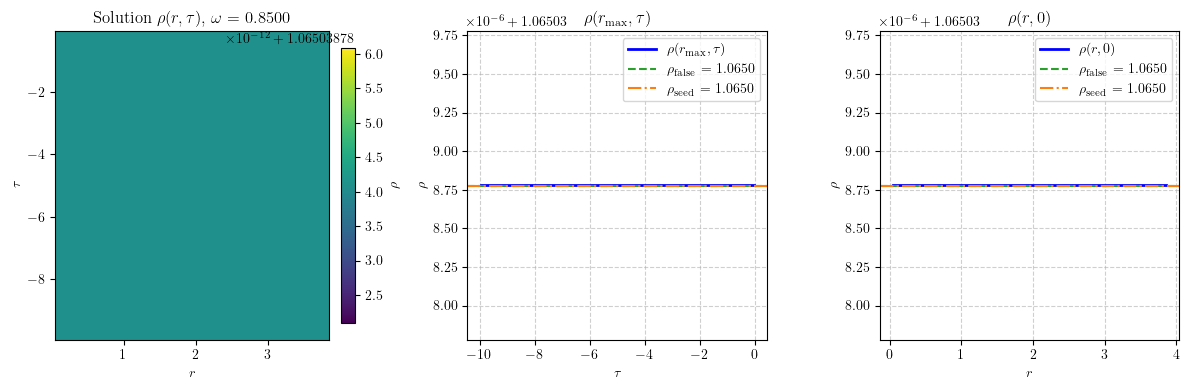

--- Final diagnostics (τ=0 ghost) ---
  Converged: True,  ||F|| = 4.656e-13
  Volume V = (4/3)π Lr³ = 239.637614

  Solution (2D Newton):
    Q(τ=0) = 231.048901,   E(τ=0) = -90.627942
    ρ_Q = Q/V = 0.964160,   ρ_E = E/V = -0.378187

  Reference homogeneous at ω = OMEGA (φ = ρ_false(OMEGA), same V):
    Q_hom = 231.049350,   E_hom = -90.628116
    ρ_Q,hom = Q_hom/V = 0.964161,   ρ_E,hom = E_hom/V = -0.378188

  Ratios (solution / homogeneous):  Q/Q_hom = 0.999998,  E/E_hom = 0.999998
  Density ratios:  ρ_Q/ρ_Q,hom = 0.999998,  ρ_E/ρ_E,hom = 0.999998
  Difference:  E - E_hom (H_E) = 0.000174
  Difference:  E_M - E_M_hom(OMEGA) = -0.000174
  F_ω (solution) = -105.763623,  F_ω,hom(OMEGA) = -105.763831
  Difference:  F_ω - F_ω,hom = 0.000208


In [12]:
# ============================================================================
# 2D analysis: homogeneous ansatz → plot → Newton → plot solution
# ω for the 2D solver: choose among OMEGA, omega_same_rho_Q, omega_same_rho_E
# ============================================================================
from Bubble_finder.bounce2d import solve_rho0_for_omega

# Choose ω for the 2D run (change to "omega_same_rho_Q" or "omega_same_rho_E" if desired)
omega_2d_choice = "OMEGA"  # or "omega_same_rho_Q" or "omega_same_rho_E"
try:
    _om_Q = omega_same_rho_Q
except NameError:
    _om_Q = None
try:
    _om_E = omega_same_rho_E
except NameError:
    _om_E = None
if omega_2d_choice == "omega_same_rho_Q" and _om_Q is not None:
    omega_2d = float(_om_Q)
elif omega_2d_choice == "omega_same_rho_E" and _om_E is not None:
    omega_2d = float(_om_E)
else:
    omega_2d = float(OMEGA)
print(f"2D run: ω = {omega_2d:.6f}  (choice: {omega_2d_choice})")

# Grid and solver (Lr from 1D bounce if available)
try:
    Lr_2d = float(r_bounce[-1]) if r_bounce is not None else 10.0
except NameError:
    Lr_2d = 10.0
Nr_2d, Ntau_2d = 80, 100
beta_2d = 20.0
# Seed at false vacuum: rho0 = ρ_false so homogeneous ansatz is φ = ρ_false
rho_false_2d, _ = vacua_of_Omega(PHI0, V1, V2, omega_2d)
rho0_2d = float(rho_false_2d)

settings_2d = Bubble2DSettings(
    Nr=Nr_2d, Ntau=Ntau_2d, Lr=Lr_2d, beta=beta_2d,
    omega_ref=omega_2d, rho0=rho0_2d, rho0_bracket=(V1 * 0.8, V2 + 0.2),
    newton_tol=1e-8, newton_max_iter=35, tau_bc="twisted",
)
solver_2d = Bubble2DSolver(settings_2d, U, dU, d2U)

# Homogeneous ansatz: y = ybar = 0 → Newton
x0_hom = solver_2d._zero_vec()
sol_2d = solver_2d.solve(x0_hom, verbose=True, verbose_success_block=False)
rho_sol = solver_2d.rho_map(sol_2d.y, sol_2d.ybar)
tau_2d = np.asarray(solver_2d.grid.tau).flatten()
r_2d = np.asarray(solver_2d.grid.r).flatten()
# Seed was prepared at ρ_false, so rho_seed = rho_false
rho_seed_2d = rho0_2d

# Color scale for solution: data range + small margin so structure is visible
vmin_rho = float(np.min(rho_sol))
vmax_rho = float(np.max(rho_sol))
delta = max(vmax_rho - vmin_rho, 1e-10)
vmin_rho -= 0.02 * delta
vmax_rho += 0.02 * delta

# Homogeneous reference always at OMEGA (φ = ρ_false(OMEGA), same V)
from Bubble_finder.observables_1d import Q_homogeneous_ball
from Bubble_finder.observables_2d import homogeneous_energy_2d, homogeneous_E_M_2d

rho_false_ref, _ = vacua_of_Omega(PHI0, V1, V2, OMEGA)
V_2d = (4.0 / 3.0) * np.pi * Lr_2d**3
Q_hom_ref = float(Q_homogeneous_ball(OMEGA, rho_false_ref, Lr_2d))
E_hom_ref = float(homogeneous_energy_2d(OMEGA, rho_false_ref, Lr_2d, U))
rho_Q_hom_ref = Q_hom_ref / V_2d
rho_E_hom_ref = E_hom_ref / V_2d

# 1) Solution ρ(r, τ) — square panel
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
tau_min_2d, tau_max_2d = float(np.min(tau_2d)), float(np.max(tau_2d))
extent_r_tau = (float(r_2d[0]), float(r_2d[-1]), tau_min_2d, tau_max_2d)
rho_sol_ordered = rho_sol.T[np.argsort(tau_2d)]
im1 = ax1.imshow(rho_sol_ordered, origin="lower", aspect="auto", extent=extent_r_tau, vmin=vmin_rho, vmax=vmax_rho)
cb1 = plt.colorbar(im1, ax=ax1, label=r"$\rho$", fraction=0.046, pad=0.04)
ax1.set_xlabel(r"$r$")
ax1.set_ylabel(r"$\tau$")
ax1.set_title(r"Solution $\rho(r,\tau)$, $\omega$ = " + f"{omega_2d:.4f}")

# 2) ρ(r_max, τ) — zoom + square
rho_at_rmax = rho_sol[-1, :]
ax2.plot(tau_2d, rho_at_rmax, "b-", lw=2, label=r"$\rho(r_{\max},\tau)$")
ax2.axhline(rho_false_2d, color="C2", ls="--", lw=1.5, label=rf"$\rho_{{\mathrm{{false}}}}$ = {rho_false_2d:.4f}")
ax2.axhline(rho_seed_2d, color="C1", ls="-.", lw=1.5, label=rf"$\rho_{{\mathrm{{seed}}}}$ = {rho_seed_2d:.4f}")
ymin_2 = min(rho_at_rmax.min(), rho_false_2d, rho_seed_2d)
ymax_2 = max(rho_at_rmax.max(), rho_false_2d, rho_seed_2d)
margin_2 = max((ymax_2 - ymin_2) * 0.1, 1e-6)
ax2.set_ylim(ymin_2 - margin_2, ymax_2 + margin_2)
ax2.set_xlabel(r"$\tau$")
ax2.set_ylabel(r"$\rho$")
ax2.set_title(r"$\rho(r_{\max},\tau)$")
#ax2.set_aspect("equal")
ax2.legend()
ax2.grid(True, ls="--", alpha=0.6)

# 3) ρ(r, 0) — slice at τ=0 (index where tau is max)
idx_tau0 = np.argmax(tau_2d)
rho_at_tau0 = rho_sol[:, idx_tau0]
ax3.plot(r_2d, rho_at_tau0, "b-", lw=2, label=r"$\rho(r,0)$")
ax3.axhline(rho_false_2d, color="C2", ls="--", lw=1.5, label=rf"$\rho_{{\mathrm{{false}}}}$ = {rho_false_2d:.4f}")
ax3.axhline(rho_seed_2d, color="C1", ls="-.", lw=1.5, label=rf"$\rho_{{\mathrm{{seed}}}}$ = {rho_seed_2d:.4f}")
ymin_3 = min(rho_at_tau0.min(), rho_false_2d, rho_seed_2d)
ymax_3 = max(rho_at_tau0.max(), rho_false_2d, rho_seed_2d)
margin_3 = max((ymax_3 - ymin_3) * 0.1, 1e-6)
ax3.set_ylim(ymin_3 - margin_3, ymax_3 + margin_3)
ax3.set_xlabel(r"$r$")
ax3.set_ylabel(r"$\rho$")
ax3.set_title(r"$\rho(r,0)$")
#ax3.set_aspect("equal")
ax3.legend()
ax3.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

Q_tau0 = float(sol_2d.Q_tau0.real)
E_tau0 = float(sol_2d.E_tau0)
rho_Q_2d = sol_2d.observables_ghost.get("rho_Q") if getattr(sol_2d, "observables_ghost", None) else (Q_tau0 / V_2d)
rho_E_2d = sol_2d.observables_ghost.get("rho_E") if getattr(sol_2d, "observables_ghost", None) else (E_tau0 / V_2d)
rho_Q_2d = float(rho_Q_2d)
rho_E_2d = float(rho_E_2d)

print("--- Final diagnostics (τ=0 ghost) ---")
print(f"  Converged: {sol_2d.success},  ||F|| = {sol_2d.residual_norm:.3e}")
print(f"  Volume V = (4/3)π Lr³ = {V_2d:.6f}")
print("")
print("  Solution (2D Newton):")
print(f"    Q(τ=0) = {Q_tau0:.6f},   E(τ=0) = {E_tau0:.6f}")
print(f"    ρ_Q = Q/V = {rho_Q_2d:.6f},   ρ_E = E/V = {rho_E_2d:.6f}")
print("")
print("  Reference homogeneous at ω = OMEGA (φ = ρ_false(OMEGA), same V):")
print(f"    Q_hom = {Q_hom_ref:.6f},   E_hom = {E_hom_ref:.6f}")
print(f"    ρ_Q,hom = Q_hom/V = {rho_Q_hom_ref:.6f},   ρ_E,hom = E_hom/V = {rho_E_hom_ref:.6f}")
print("")
print(f"  Ratios (solution / homogeneous):  Q/Q_hom = {Q_tau0/Q_hom_ref:.6f},  E/E_hom = {E_tau0/E_hom_ref:.6f}")
print(f"  Density ratios:  ρ_Q/ρ_Q,hom = {rho_Q_2d/rho_Q_hom_ref:.6f},  ρ_E/ρ_E,hom = {rho_E_2d/rho_E_hom_ref:.6f}")
print(f"  Difference:  E - E_hom (H_E) = {E_tau0 - E_hom_ref:.6f}")
obs_2d = getattr(sol_2d, "observables_ghost", None) or {}
E_M_hom_ref = float(homogeneous_E_M_2d(OMEGA, rho_false_ref, Lr_2d, U))
if "E_M" in obs_2d:
    print(f"  Difference:  E_M - E_M_hom(OMEGA) = {obs_2d['E_M'] - E_M_hom_ref:.6f}")
if "F_omega" in obs_2d:
    F_hom_ref = E_M_hom_ref - OMEGA * Q_hom_ref
    print(f"  F_ω (solution) = {obs_2d['F_omega']:.6f},  F_ω,hom(OMEGA) = {F_hom_ref:.6f}")
    print(f"  Difference:  F_ω - F_ω,hom = {obs_2d['F_omega'] - F_hom_ref:.6f}")

**Gated bubble: ansatz from 1D bounce + τ-gate → Newton with iteration history.**

This cell repeats the same 2D analysis (same ω choice, same diagnostics) but starts from a **gated bubble** ansatz: the 1D critical bounce profile $\phi(r)$ is modulated by a smooth gate in τ so the bubble is localized in Euclidean time. You can choose **ω** as **OMEGA**, **omega_same_rho_Q**, or **omega_same_rho_E**. The center and right panels plot not only the final solution but **all Newton iterations** (including the initial gated ansatz) so you can see how the solution is reached.

Gated 2D run: ω = 0.850000  (choice: OMEGA)
[vacua_of_Omega] ω=0.85
  phi_false=1.06503877578  Ω_false=-1.2608862793  dΩ=-5.29e-08  (ω²-W)=2.48e-08  Ω''=1.244e+01
  phi_true =2.09465574669  Ω_true =-4.54571225238  dΩ=-3.65e-07  (ω²-W)=8.71e-08  Ω''=4.175e+01
[Newton-explicit] iter=01, ||F||=9.674e+00, rhoQ=9.752405e-01, rhoE=-4.025015e-01, rho_Q/rho_Q_ref=1.0115, rho_E/rho_E_ref=1.0643
[Newton-explicit] iter=02, ||F||=5.548e+00, rhoQ=9.710439e-01, rhoE=-3.990740e-01, rho_Q/rho_Q_ref=1.0071, rho_E/rho_E_ref=1.0552
[Newton-explicit] iter=03, ||F||=2.117e+00, rhoQ=9.664106e-01, rhoE=-3.928207e-01, rho_Q/rho_Q_ref=1.0023, rho_E/rho_E_ref=1.0387
[Newton-explicit] iter=04, ||F||=1.118e-01, rhoQ=9.660592e-01, rhoE=-3.917280e-01, rho_Q/rho_Q_ref=1.0020, rho_E/rho_E_ref=1.0358
[Newton-explicit] iter=05, ||F||=2.428e-04, rhoQ=9.660673e-01, rhoE=-3.917263e-01, rho_Q/rho_Q_ref=1.0020, rho_E/rho_E_ref=1.0358
[Newton-explicit] iter=06, ||F||=4.113e-09, rhoQ=9.660673e-01, rhoE=-3.917262e-01, rho_Q/rh

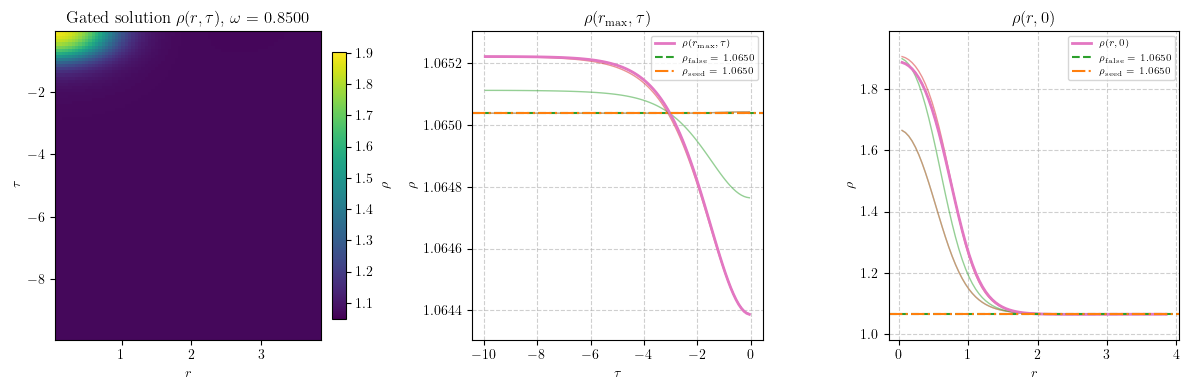

--- Gated bubble diagnostics (τ=0 ghost) ---
  Converged: True,  ||F|| = 4.113e-09
  Volume V = (4/3)π Lr³ = 239.637614

  Solution (2D Newton from gated ansatz):
    Q(τ=0) = 231.506066,   E(τ=0) = -93.872334
    ρ_Q = Q/V = 0.966067,   ρ_E = E/V = -0.391726

  Reference homogeneous at ω = OMEGA (φ = ρ_false(OMEGA), same V):
    Q_hom = 231.049350,   E_hom = -90.628116
    ρ_Q,hom = Q_hom/V = 0.964161,   ρ_E,hom = E_hom/V = -0.378188

  Ratios (solution / homogeneous):  Q/Q_hom = 1.001977,  E/E_hom = 1.035797
  Density ratios:  ρ_Q/ρ_Q,hom = 1.001977,  ρ_E/ρ_E,hom = 1.035797
  Difference:  E - E_hom (H_E) = -3.244218
  Difference:  E_M - E_M_hom(OMEGA) = 3.244218
  F_ω (solution) = -102.907822,  F_ω,hom(OMEGA) = -105.763831
  Difference:  F_ω - F_ω,hom = 2.856009


In [13]:
# ============================================================================
# Gated bubble: 1D bounce + τ-gate → Newton (store_iteration_history=True)
# ω choice: OMEGA, omega_same_rho_Q, or omega_same_rho_E
# ============================================================================
from Bubble_finder.ansatz_bubble import tau_gate, AnsatzParams
from Bubble_finder.bounce_1d import solve_bounce
from Bubble_finder.observables_1d import Q_homogeneous_ball
from Bubble_finder.observables_2d import homogeneous_energy_2d, homogeneous_E_M_2d

# Same ω choice as the homogeneous 2D cell
omega_gated_choice = "OMEGA"  # or "omega_same_rho_Q" or "omega_same_rho_E"
try:
    _om_Q = omega_same_rho_Q
except NameError:
    _om_Q = None
try:
    _om_E = omega_same_rho_E
except NameError:
    _om_E = None
if omega_gated_choice == "omega_same_rho_Q" and _om_Q is not None:
    omega_2d_g = float(_om_Q)
elif omega_gated_choice == "omega_same_rho_E" and _om_E is not None:
    omega_2d_g = float(_om_E)
else:
    omega_2d_g = float(OMEGA)
print(f"Gated 2D run: ω = {omega_2d_g:.6f}  (choice: {omega_gated_choice})")

# Grid size (same as homogeneous 2D)
try:
    Lr_2d_g = float(r_bounce[-1]) if r_bounce is not None else 10.0
except NameError:
    Lr_2d_g = 10.0
Nr_2d_g, Ntau_2d_g = 80, 100
beta_2d_g = 20.0
rho_false_2d_g, _ = vacua_of_Omega(PHI0, V1, V2, omega_2d_g)
rho0_2d_g = float(rho_false_2d_g)

# 1D bounce at omega_2d_g for the gated ansatz
try:
    RMAX_1d = float(RMAX)
except NameError:
    RMAX_1d = Lr_2d_g
r_1d_g, phi_1d_g, _, _, _ = solve_bounce(
    PHI0, V1, V2, omega_2d_g,
    d=3, r0=1e-6, rmax=RMAX_1d, max_iter=150, verbose=False,
)
r_1d_g = np.asarray(r_1d_g, float)
phi_1d_g = np.asarray(phi_1d_g, float)

# Solver (same settings as homogeneous 2D)
settings_2d_g = Bubble2DSettings(
    Nr=Nr_2d_g, Ntau=Ntau_2d_g, Lr=Lr_2d_g, beta=beta_2d_g,
    omega_ref=omega_2d_g, rho0=rho0_2d_g, rho0_bracket=(V1 * 0.8, V2 + 0.2),
    newton_tol=1e-8, newton_max_iter=35, tau_bc="twisted",
)
solver_2d_g = Bubble2DSolver(settings_2d_g, U, dU, d2U)


# Gated ansatz: 1D profile × tau gate
r_grid_g = np.asarray(solver_2d_g.grid.r).flatten()
tau_grid_g = np.asarray(solver_2d_g.grid.tau).flatten()
T_g = beta_2d_g / 2.0
params_gated = AnsatzParams(eps=1.0, k=1, phase=0.0, amp=1.0, tau_gate_frac=0.25, tau_gate_center_frac=1, r_window_frac=0.15)
phi_on_r_g = np.interp(r_grid_g, r_1d_g, phi_1d_g, left=phi_1d_g[0], right=phi_1d_g[-1])
y_slice_g = r_grid_g * (phi_on_r_g - solver_2d_g.rho0)
g_tau = tau_gate(tau_grid_g, T_g, params_gated.tau_gate_frac, center_frac=params_gated.tau_gate_center_frac)
y_gated = params_gated.amp * np.outer(y_slice_g, g_tau).astype(complex)
ybar_gated = y_gated.copy()
x0_gated = solver_2d_g.pack(y_gated, ybar_gated)
rho_seed_2d_g = rho0_2d_g

# Newton with iteration history
sol_2d_g = solver_2d_g.solve(x0_gated, verbose=True, verbose_success_block=False, store_iteration_history=True)
rho_sol_g = solver_2d_g.rho_map(sol_2d_g.y, sol_2d_g.ybar)
tau_2d_g = np.asarray(solver_2d_g.grid.tau).flatten()
r_2d_g = np.asarray(solver_2d_g.grid.r).flatten()

# Color scale
vmin_rho_g = float(np.min(rho_sol_g))
vmax_rho_g = float(np.max(rho_sol_g))
delta_g = max(vmax_rho_g - vmin_rho_g, 1e-10)
vmin_rho_g -= 0.02 * delta_g
vmax_rho_g += 0.02 * delta_g

# Homogeneous reference always at OMEGA (φ = ρ_false(OMEGA), same V)
rho_false_ref_g, _ = vacua_of_Omega(PHI0, V1, V2, OMEGA)
V_2d_g = (4.0 / 3.0) * np.pi * Lr_2d_g**3
Q_hom_ref_g = float(Q_homogeneous_ball(OMEGA, rho_false_ref_g, Lr_2d_g))
E_hom_ref_g = float(homogeneous_energy_2d(OMEGA, rho_false_ref_g, Lr_2d_g, U))
rho_Q_hom_ref_g = Q_hom_ref_g / V_2d_g
rho_E_hom_ref_g = E_hom_ref_g / V_2d_g

# Plot: (1) solution; (2) ρ(r_max, τ) with iterations; (3) ρ(r, 0) with iterations
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
tau_min_2d_g, tau_max_2d_g = float(np.min(tau_2d_g)), float(np.max(tau_2d_g))
extent_r_tau_g = (float(r_2d_g[0]), float(r_2d_g[-1]), tau_min_2d_g, tau_max_2d_g)
rho_sol_g_ordered = rho_sol_g.T[np.argsort(tau_2d_g)]
im1 = ax1.imshow(rho_sol_g_ordered, origin="lower", aspect="auto", extent=extent_r_tau_g, vmin=vmin_rho_g, vmax=vmax_rho_g)
plt.colorbar(im1, ax=ax1, label=r"$\rho$", fraction=0.046, pad=0.04)
ax1.set_xlabel(r"$r$")
ax1.set_ylabel(r"$\tau$")
ax1.set_title(r"Gated solution $\rho(r,\tau)$, $\omega$ = " + f"{omega_2d_g:.4f}")

# Center: ρ(r_max, τ) — all iterations + final + refs
hist = sol_2d_g.iteration_history or []
n_hist = len(hist)
print("Newton iterations:", [h["iter"] for h in hist])
for i, h in enumerate(hist):
    rho_2d = h["rho"]
    if rho_2d.ndim == 2:
        rho_rmax = rho_2d[-1, :]
    else:
        rho_rmax = np.reshape(rho_2d, (len(r_2d_g), len(tau_2d_g)))[-1, :]
    lab = r"$\rho(r_{\max},\tau)$" if i == n_hist - 1 else "_nolegend_"
    ax2.plot(tau_2d_g, rho_rmax, alpha=0.5 + 0.5 * (i == n_hist - 1), lw=1 if i < n_hist - 1 else 2, label=lab)
ax2.axhline(rho_false_2d_g, color="C2", ls="--", lw=1.5, label=rf"$\rho_{{\mathrm{{false}}}}$ = {rho_false_2d_g:.4f}")
ax2.axhline(rho_seed_2d_g, color="C1", ls="-.", lw=1.5, label=rf"$\rho_{{\mathrm{{seed}}}}$ = {rho_seed_2d_g:.4f}")
all_rmax = np.concatenate([(h["rho"][-1, :] if h["rho"].ndim == 2 else np.reshape(h["rho"], (len(r_2d_g), len(tau_2d_g)))[-1, :]) for h in hist])
ymin_2 = min(all_rmax.min(), rho_false_2d_g, rho_seed_2d_g)
ymax_2 = max(all_rmax.max(), rho_false_2d_g, rho_seed_2d_g)
margin_2 = max((ymax_2 - ymin_2) * 0.1, 1e-6)
ax2.set_ylim(ymin_2 - margin_2, ymax_2 + margin_2)
ax2.set_xlabel(r"$\tau$")
ax2.set_ylabel(r"$\rho$")
ax2.set_title(r"$\rho(r_{\max},\tau)$")
ax2.legend(loc="best", fontsize=7)
ax2.grid(True, ls="--", alpha=0.6)

# Right: ρ(r, 0) — slice at τ=0 (index where tau is max)
idx_tau0_g = np.argmax(tau_2d_g)
for i, h in enumerate(hist):
    rho_2d = h["rho"]
    if rho_2d.ndim == 2:
        rho_t0 = rho_2d[:, idx_tau0_g]
    else:
        rho_t0 = np.reshape(rho_2d, (len(r_2d_g), len(tau_2d_g)))[:, idx_tau0_g]
    lab = r"$\rho(r,0)$" if i == n_hist - 1 else "_nolegend_"
    ax3.plot(r_2d_g, rho_t0, alpha=0.5 + 0.5 * (i == n_hist - 1), lw=1 if i < n_hist - 1 else 2, label=lab)
ax3.axhline(rho_false_2d_g, color="C2", ls="--", lw=1.5, label=rf"$\rho_{{\mathrm{{false}}}}$ = {rho_false_2d_g:.4f}")
ax3.axhline(rho_seed_2d_g, color="C1", ls="-.", lw=1.5, label=rf"$\rho_{{\mathrm{{seed}}}}$ = {rho_seed_2d_g:.4f}")
all_r0 = np.concatenate([(h["rho"][:, idx_tau0_g] if h["rho"].ndim == 2 else np.reshape(h["rho"], (len(r_2d_g), len(tau_2d_g)))[:, idx_tau0_g]) for h in hist])
ymin_3 = min(all_r0.min(), rho_false_2d_g, rho_seed_2d_g)
ymax_3 = max(all_r0.max(), rho_false_2d_g, rho_seed_2d_g)
margin_3 = max((ymax_3 - ymin_3) * 0.1, 1e-6)
ax3.set_ylim(ymin_3 - margin_3, ymax_3 + margin_3)
ax3.set_xlabel(r"$r$")
ax3.set_ylabel(r"$\rho$")
ax3.set_title(r"$\rho(r,0)$")
ax3.legend(loc="best", fontsize=7)
ax3.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Diagnostics (same as homogeneous 2D)
Q_tau0_g = float(sol_2d_g.Q_tau0.real)
E_tau0_g = float(sol_2d_g.E_tau0)
rho_Q_2d_g = sol_2d_g.observables_ghost.get("rho_Q") if getattr(sol_2d_g, "observables_ghost", None) else (Q_tau0_g / V_2d_g)
rho_E_2d_g = sol_2d_g.observables_ghost.get("rho_E") if getattr(sol_2d_g, "observables_ghost", None) else (E_tau0_g / V_2d_g)
rho_Q_2d_g = float(rho_Q_2d_g)
rho_E_2d_g = float(rho_E_2d_g)

print("--- Gated bubble diagnostics (τ=0 ghost) ---")
print(f"  Converged: {sol_2d_g.success},  ||F|| = {sol_2d_g.residual_norm:.3e}")
print(f"  Volume V = (4/3)π Lr³ = {V_2d_g:.6f}")
print("")
print("  Solution (2D Newton from gated ansatz):")
print(f"    Q(τ=0) = {Q_tau0_g:.6f},   E(τ=0) = {E_tau0_g:.6f}")
print(f"    ρ_Q = Q/V = {rho_Q_2d_g:.6f},   ρ_E = E/V = {rho_E_2d_g:.6f}")
print("")
print("  Reference homogeneous at ω = OMEGA (φ = ρ_false(OMEGA), same V):")
print(f"    Q_hom = {Q_hom_ref_g:.6f},   E_hom = {E_hom_ref_g:.6f}")
print(f"    ρ_Q,hom = Q_hom/V = {rho_Q_hom_ref_g:.6f},   ρ_E,hom = E_hom/V = {rho_E_hom_ref_g:.6f}")
print("")
print(f"  Ratios (solution / homogeneous):  Q/Q_hom = {Q_tau0_g/Q_hom_ref_g:.6f},  E/E_hom = {E_tau0_g/E_hom_ref_g:.6f}")
print(f"  Density ratios:  ρ_Q/ρ_Q,hom = {rho_Q_2d_g/rho_Q_hom_ref_g:.6f},  ρ_E/ρ_E,hom = {rho_E_2d_g/rho_E_hom_ref_g:.6f}")
print(f"  Difference:  E - E_hom (H_E) = {E_tau0_g - E_hom_ref_g:.6f}")
obs_2d_g = getattr(sol_2d_g, "observables_ghost", None) or {}
E_M_hom_ref_g = float(homogeneous_E_M_2d(OMEGA, rho_false_ref_g, Lr_2d_g, U))
if "E_M" in obs_2d_g:
    print(f"  Difference:  E_M - E_M_hom(OMEGA) = {obs_2d_g['E_M'] - E_M_hom_ref_g:.6f}")
if "F_omega" in obs_2d_g:
    F_2d_g = obs_2d_g["F_omega"]
    F_hom_g = E_M_hom_ref_g - OMEGA * Q_hom_ref_g
    print(f"  F_ω (solution) = {F_2d_g:.6f},  F_ω,hom(OMEGA) = {F_hom_g:.6f}")
    print(f"  Difference:  F_ω - F_ω,hom = {F_2d_g - F_hom_g:.6f}")

**Resample → β=50, Lr=50 (finer grid) → Newton → η₀ scan (match Q) → plot.**

This cell uses as ansatz for resampling the **converged Newton solution with the bubble** from the previous cell (gated bubble → Newton → `sol_2d_g`). That solution is resampled onto a new grid with **β=50**, **Lr=50** and a finer discretization (larger Nr, Nτ); then one Newton solve, an **η₀ scan** (bisection) to match the charge to the homogeneous reference, and the three panels (solution ρ(r,τ), ρ(r_max,τ), ρ(r,0)) without iteration history.

[vacua_of_Omega] ω=0.85
  phi_false=1.06503877578  Ω_false=-1.2608862793  dΩ=-5.29e-08  (ω²-W)=2.48e-08  Ω''=1.244e+01
  phi_true =2.09465574669  Ω_true =-4.54571225238  dΩ=-3.65e-07  (ω²-W)=8.71e-08  Ω''=4.175e+01
[Newton-explicit] iter=01, ||F||=6.333e+01, rhoQ=9.630981e-01, rhoE=-3.772454e-01, rho_Q/rho_Q_ref=0.9989, rho_E/rho_E_ref=0.9975
[Newton-explicit] iter=02, ||F||=2.926e-02, rhoQ=9.642621e-01, rhoE=-3.789393e-01, rho_Q/rho_Q_ref=1.0001, rho_E/rho_E_ref=1.0020
[Newton-explicit] iter=03, ||F||=2.382e-06, rhoQ=9.642621e-01, rhoE=-3.789393e-01, rho_Q/rho_Q_ref=1.0001, rho_E/rho_E_ref=1.0020
[Newton-explicit] iter=04, ||F||=3.167e-12, rhoQ=9.642621e-01, rhoE=-3.789393e-01, rho_Q/rho_Q_ref=1.0001, rho_E/rho_E_ref=1.0020
[eta-scan] target:  Q_target = 4038.6700578171267 ,  E_hom_ref = -1584.151002187964 ,  V = 4188.790204786391
[eta-scan]         ρ_Q,hom = Q_target/V = 0.9641614548282397 ,  ρ_E,hom = -0.37818819390329156
[eta-scan] eta = 0.000000, charge = 4.039092e+03, energy = -1

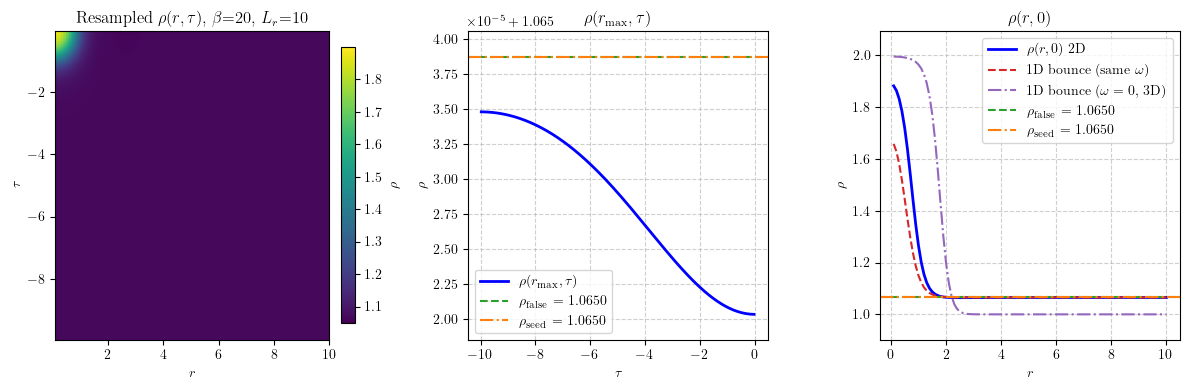

--- Resampled + η scan: full diagnostics ---
  Homogeneous reference: ω = OMEGA = 0.850000
  Grid: β = 20.0, Lr = 10.0, Nr = 100, Nτ = 200
  Volume V = (4/3)π Lr³ = 4188.790205
  η₀* = -0.001440

  Solution (2D after resample + Newton + η scan):
    Q(τ=0) = 4038.670058,   E(τ=0) = -1586.581513
    ρ_Q = Q/V = 0.964161,   ρ_E = E/V = -0.378768

  Reference homogeneous at ω = OMEGA (φ = ρ_false(OMEGA), same V):
    Q_hom = 4038.670058,   E_hom = -1584.151002
    ρ_Q,hom = Q_hom/V = 0.964161,   ρ_E,hom = E_hom/V = -0.378188

  Ratios (solution / homogeneous):  Q/Q_hom = 1.000000,  E/E_hom = 1.001534
  Density ratios:  ρ_Q/ρ_Q,hom = 1.000000,  ρ_E/ρ_E,hom = 1.001534
  Difference:  E - E_hom (H_E) = -2.430511
  Difference:  E_M - E_M_hom(OMEGA) = 2.430511
  F_ω (solution) = -1846.288036,  F_ω,hom(OMEGA) = -1848.718547
  Difference:  F_ω - F_ω,hom = 2.430511


In [14]:
# Resample gated solution to beta=50, Lr=50, finer grid → Newton → eta0 scan → plot
from Q_ball_finder.notebook_utils import resample_complex_field
from scipy.optimize import brentq
from Bubble_finder.bounce2d import Bubble2DSettings, Bubble2DSolver
from Bubble_finder.observables_1d import Q_homogeneous_ball
from Bubble_finder.observables_2d import homogeneous_energy_2d, homogeneous_E_M_2d

# New grid: beta=50, Lr=50, finer (more points)
beta_res = 20.0
Lr_res = 10.0
Nr_res = 100
Ntau_res = 200
omega_res = float(omega_2d_g)
rho0_res = float(rho0_2d_g)
rho_false_res = float(rho_false_2d_g)
rho_false_ref_res, _ = vacua_of_Omega(PHI0, V1, V2, OMEGA)

# Ansatz for resampling: converged Newton solution with the bubble (gated → Newton → sol_2d_g)
r_old = np.asarray(solver_2d_g.grid.r).flatten()
tau_old = np.asarray(solver_2d_g.grid.tau).flatten()
y_old = sol_2d_g.y
ybar_old = sol_2d_g.ybar

# New solver (builds new grid)
settings_res = Bubble2DSettings(
    Nr=Nr_res, Ntau=Ntau_res, Lr=Lr_res, beta=beta_res,
    omega_ref=omega_res, rho0=rho0_res, rho0_bracket=(V1 * 0.8, V2 + 0.2),
    newton_tol=1e-8, newton_max_iter=35, tau_bc="twisted",
)
solver_res = Bubble2DSolver(settings_res, U, dU, d2U)
r_new = np.asarray(solver_res.grid.r).flatten()
tau_new = np.asarray(solver_res.grid.tau).flatten()

# Resample y, ybar onto new grid
y_res = resample_complex_field(y_old, r_old, tau_old, r_new, tau_new, clamp_tau_to_plateau=True)
ybar_res = resample_complex_field(ybar_old, r_old, tau_old, r_new, tau_new, clamp_tau_to_plateau=True)
x0_res = solver_res.pack(y_res, ybar_res)

# One Newton solve (no iteration history)
sol_res = solver_res.solve(x0_res, verbose=True, verbose_success_block=False, store_iteration_history=False)

# eta0 scan: target Q = homogeneous at OMEGA (same grid volume)
V_res = (4.0 / 3.0) * np.pi * Lr_res**3
Q_target_res = float(Q_homogeneous_ball(OMEGA, rho_false_ref_res, Lr_res))
Q_hom_res = float(Q_homogeneous_ball(OMEGA, rho_false_ref_res, Lr_res))
E_hom_res = float(homogeneous_energy_2d(OMEGA, rho_false_ref_res, Lr_res, U))
verbose_eta_scan = True  # set False to silence [eta-scan] lines

def solve_at_eta(solver, eta, x0, verbose=False):
    solver.settings.eta0 = float(eta)
    solver.eta0 = float(eta)
    sol = solver.solve(x0, verbose=verbose, verbose_success_block=False)
    return float(sol.Q_tau0.real), sol

def eta_scan_at_beta(solver, eta_start, x_seed, Q_target, V_ref, Q_hom_ref, E_hom_ref, d_eta=0.05, max_steps=80, tol_Q=1e-6, verbose=True):
    """Bracket eta con Q che attraversa Q_target, poi brentq. Q diminuisce con eta (dQ/dη < 0). Output come bubble_2D."""
    tol_Q = tol_Q * max(1.0, abs(Q_target))
    eta_cache = {}
    eta_cache_precision = 1e-12
    E_Q_ref = E_hom_ref if (E_hom_ref and abs(E_hom_ref) > 1e-30) else 1.0
    eta_curr = eta_start
    Q_curr, sol_curr = solve_at_eta(solver, eta_curr, x_seed, verbose=False)
    x_seed = sol_curr.x.copy()
    E_curr = float(sol_curr.E_tau0)
    ratioQ = (Q_curr / Q_target) if Q_target and abs(Q_target) > 1e-30 else 0.0
    ratioE = (E_curr / E_Q_ref) if E_Q_ref else 0.0
    eta_cache[round(eta_curr / eta_cache_precision) * eta_cache_precision] = (Q_curr, E_curr, ratioQ, ratioE)
    if abs(Q_curr - Q_target) < tol_Q:
        if verbose:
            print(f"[eta-scan] eta* = {eta_curr:.6f}, charge = {Q_curr:.6e}, energy = {E_curr:.6e}, ratioQ = {ratioQ:.6f}, ratioE = {ratioE:.6f}")
        return eta_curr, sol_curr, x_seed, dict(Q=Q_curr, E=E_curr)
    if verbose:
        print(f"[eta-scan] eta = {eta_curr:.6f}, charge = {Q_curr:.6e}, energy = {E_curr:.6e}, target = {Q_target:.6e}, ratioQ = {ratioQ:.6f}")
    eta_prev, Q_prev = eta_curr, Q_curr
    for _ in range(max_steps):
        if Q_curr < Q_target:
            eta_prev, Q_prev = eta_curr, Q_curr
            eta_curr += d_eta
        else:
            eta_prev, Q_prev = eta_curr, Q_curr
            eta_curr -= d_eta
        Q_curr, sol_curr = solve_at_eta(solver, eta_curr, x_seed, verbose=False)
        x_seed = sol_curr.x.copy()
        E_curr = float(sol_curr.E_tau0)
        ratioQ = (Q_curr / Q_target) if Q_target and abs(Q_target) > 1e-30 else 0.0
        ratioE = (E_curr / E_Q_ref) if E_Q_ref else 0.0
        eta_cache[round(eta_curr / eta_cache_precision) * eta_cache_precision] = (Q_curr, E_curr, ratioQ, ratioE)
        if verbose:
            print(f"[eta-scan] try eta = {eta_curr:.6f}, charge = {Q_curr:.6e}, energy = {E_curr:.6e}, ratioQ = {ratioQ:.6f}, ratioE = {ratioE:.6f}")
        if (Q_prev - Q_target) * (Q_curr - Q_target) <= 0:
            break
    else:
        raise RuntimeError("eta scan did not cross Q_target within max_steps")
    eta_lo, eta_hi = (eta_curr, eta_prev) if Q_prev < Q_target else (eta_prev, eta_curr)
    state = {"x_seed": x_seed}

    def f_eta(eta):
        eta_f = float(eta)
        key = round(eta_f / eta_cache_precision) * eta_cache_precision
        if key in eta_cache:
            q, e, rq, re = eta_cache[key]
            if verbose:
                print(f"[eta-root] eta = {eta_f:.6f} (cached), charge = {q:.6e}, energy = {e:.6e}, ratioQ = {rq:.6f}, ratioE = {re:.6f}")
            return q - Q_target
        q, s = solve_at_eta(solver, eta_f, state["x_seed"], verbose=False)
        state["x_seed"] = s.x.copy()
        e = float(s.E_tau0)
        rq = (q / Q_target) if Q_target and abs(Q_target) > 1e-30 else 0.0
        re = (e / E_Q_ref) if E_Q_ref else 0.0
        eta_cache[key] = (q, e, rq, re)
        if verbose:
            print(f"[eta-root] eta = {eta_f:.6f}, charge = {q:.6e}, energy = {e:.6e}, ratioQ = {rq:.6f}, ratioE = {re:.6f}")
        return q - Q_target

    eta_star = float(brentq(f_eta, eta_lo, eta_hi, xtol=1e-10))
    _, sol_final = solve_at_eta(solver, eta_star, state["x_seed"], verbose=False)
    x_seed = sol_final.x.copy()
    Q_final = float(sol_final.Q_tau0.real)
    E_final = float(sol_final.E_tau0)
    ratioQ_f = (Q_final / Q_target) if Q_target and abs(Q_target) > 1e-30 else 0.0
    ratioE_f = (E_final / E_Q_ref) if E_Q_ref else 0.0
    if verbose:
        print(f"[eta-scan] eta* = {eta_star:.6f}, charge = {Q_final:.6e}, energy = {E_final:.6e}, ratioQ = {ratioQ_f:.6f}, ratioE = {ratioE_f:.6f}")
    return eta_star, sol_final, x_seed, dict(Q=Q_final, E=E_final)

# Diagnostica target prima dello scan su eta
print("[eta-scan] target:  Q_target =", Q_target_res, ",  E_hom_ref =", E_hom_res, ",  V =", V_res)
print("[eta-scan]         ρ_Q,hom = Q_target/V =", Q_target_res / V_res, ",  ρ_E,hom =", E_hom_res / V_res)

eta_star_res, sol_eta_res, _, dens_res = eta_scan_at_beta(
    solver_res, 0.0, sol_res.x.copy(), Q_target_res, V_res, Q_hom_res, E_hom_res,
    d_eta=0.05, tol_Q=1e-12, verbose=verbose_eta_scan
)
print(f"η₀* = {eta_star_res:.6f},  Q = {dens_res['Q']:.6f},  E = {dens_res['E']:.6f}")

# Solution to plot (after eta scan)
rho_sol_res = solver_res.rho_map(sol_eta_res.y, sol_eta_res.ybar)
tau_res = np.asarray(solver_res.grid.tau).flatten()
r_res = np.asarray(solver_res.grid.r).flatten()
V_res = (4.0 / 3.0) * np.pi * Lr_res**3
vmin_res = float(np.min(rho_sol_res))
vmax_res = float(np.max(rho_sol_res))
delta_res = max(vmax_res - vmin_res, 1e-10)
vmin_res -= 0.02 * delta_res
vmax_res += 0.02 * delta_res

# Three panels (no iterations)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
tau_min_res = float(np.min(tau_res))
tau_max_res = float(np.max(tau_res))
extent_res = (float(r_res[0]), float(r_res[-1]), tau_min_res, tau_max_res)
rho_ordered_res = rho_sol_res.T[np.argsort(tau_res)]
im1 = ax1.imshow(rho_ordered_res, origin="lower", aspect="auto", extent=extent_res, vmin=vmin_res, vmax=vmax_res)
plt.colorbar(im1, ax=ax1, label=r"$\rho$", fraction=0.046, pad=0.04)
ax1.set_xlabel(r"$r$")
ax1.set_ylabel(r"$\tau$")
ax1.set_title(r"Resampled $\rho(r,\tau)$, $\beta$=" + f"{beta_res:.0f}, $L_r$=" + f"{Lr_res:.0f}")

rho_at_rmax_res = rho_sol_res[-1, :]
ax2.plot(tau_res, rho_at_rmax_res, "b-", lw=2, label=r"$\rho(r_{\max},\tau)$")
ax2.axhline(rho_false_res, color="C2", ls="--", lw=1.5, label=rf"$\rho_{{\mathrm{{false}}}}$ = {rho_false_res:.4f}")
ax2.axhline(rho0_res, color="C1", ls="-.", lw=1.5, label=rf"$\rho_{{\mathrm{{seed}}}}$ = {rho0_res:.4f}")
ymin_2 = min(rho_at_rmax_res.min(), rho_false_res, rho0_res)
ymax_2 = max(rho_at_rmax_res.max(), rho_false_res, rho0_res)
margin_2 = max((ymax_2 - ymin_2) * 0.1, 1e-6)
ax2.set_ylim(ymin_2 - margin_2, ymax_2 + margin_2)
ax2.set_xlabel(r"$\tau$")
ax2.set_ylabel(r"$\rho$")
ax2.set_title(r"$\rho(r_{\max},\tau)$")
ax2.legend()
ax2.grid(True, ls="--", alpha=0.6)

# Slice at τ=0 (index where tau is max)
idx_tau0_res = np.argmax(tau_res)
rho_at_tau0_res = rho_sol_res[:, idx_tau0_res]
# 1D bounces for comparison: same ω and ω=0 (3D)
from Bubble_finder.bounce_1d import solve_bounce
r_1d_same, phi_1d_same, _, _, _ = solve_bounce(
    PHI0, V1, V2, omega_res, d=3, r0=1e-6, rmax=Lr_res, max_iter=150, verbose=False
)
r_1d_w0, phi_1d_w0, _, _, _ = solve_bounce(
    PHI0, V1, V2, 0.0, d=3, r0=1e-6, rmax=Lr_res, max_iter=150, verbose=False
)
ax3.plot(r_res, rho_at_tau0_res, "b-", lw=2, label=r"$\rho(r,0)$ 2D")
phi_1d_same_on_r = np.interp(r_res, r_1d_same, phi_1d_same)
ax3.plot(r_res, phi_1d_same_on_r, "C3--", lw=1.5, label=r"1D bounce (same $\omega$)")
phi_1d_w0_on_r = np.interp(r_res, r_1d_w0, phi_1d_w0)
ax3.plot(r_res, phi_1d_w0_on_r, "C4-.", lw=1.5, label=r"1D bounce ($\omega=0$, 3D)")
ax3.axhline(rho_false_res, color="C2", ls="--", lw=1.5, label=rf"$\rho_{{\mathrm{{false}}}}$ = {rho_false_res:.4f}")
ax3.axhline(rho0_res, color="C1", ls="-.", lw=1.5, label=rf"$\rho_{{\mathrm{{seed}}}}$ = {rho0_res:.4f}")
ymin_3 = min(rho_at_tau0_res.min(), phi_1d_same_on_r.min(), phi_1d_w0_on_r.min(), rho_false_res, rho0_res)
ymax_3 = max(rho_at_tau0_res.max(), phi_1d_same_on_r.max(), phi_1d_w0_on_r.max(), rho_false_res, rho0_res)
margin_3 = max((ymax_3 - ymin_3) * 0.1, 1e-6)
ax3.set_ylim(ymin_3 - margin_3, ymax_3 + margin_3)
ax3.set_xlabel(r"$r$")
ax3.set_ylabel(r"$\rho$")
ax3.set_title(r"$\rho(r,0)$")
ax3.legend()
ax3.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Full diagnostics: 2D solution vs reference homogeneous at OMEGA (V_res, Q_hom_res, E_hom_res already computed above)
rho_Q_hom_res = Q_hom_res / V_res
rho_E_hom_res = E_hom_res / V_res
rho_Q_res = dens_res["Q"] / V_res
rho_E_res = dens_res["E"] / V_res
print("--- Resampled + η scan: full diagnostics ---")
print(f"  Homogeneous reference: ω = OMEGA = {OMEGA:.6f}")
print(f"  Grid: β = {beta_res}, Lr = {Lr_res}, Nr = {Nr_res}, Nτ = {Ntau_res}")
print(f"  Volume V = (4/3)π Lr³ = {V_res:.6f}")
print(f"  η₀* = {eta_star_res:.6f}")
print("")
print("  Solution (2D after resample + Newton + η scan):")
print(f"    Q(τ=0) = {dens_res['Q']:.6f},   E(τ=0) = {dens_res['E']:.6f}")
print(f"    ρ_Q = Q/V = {rho_Q_res:.6f},   ρ_E = E/V = {rho_E_res:.6f}")
print("")
print("  Reference homogeneous at ω = OMEGA (φ = ρ_false(OMEGA), same V):")
print(f"    Q_hom = {Q_hom_res:.6f},   E_hom = {E_hom_res:.6f}")
print(f"    ρ_Q,hom = Q_hom/V = {rho_Q_hom_res:.6f},   ρ_E,hom = E_hom/V = {rho_E_hom_res:.6f}")
print("")
print(f"  Ratios (solution / homogeneous):  Q/Q_hom = {dens_res['Q']/Q_hom_res:.6f},  E/E_hom = {dens_res['E']/E_hom_res:.6f}")
print(f"  Density ratios:  ρ_Q/ρ_Q,hom = {rho_Q_res/rho_Q_hom_res:.6f},  ρ_E/ρ_E,hom = {rho_E_res/rho_E_hom_res:.6f}")
print(f"  Difference:  E - E_hom (H_E) = {dens_res['E'] - E_hom_res:.6f}")
obs_res = getattr(sol_eta_res, "observables_ghost", None) or {}
E_M_hom_res = float(homogeneous_E_M_2d(OMEGA, rho_false_ref_res, Lr_res, U))
if "E_M" in obs_res:
    print(f"  Difference:  E_M - E_M_hom(OMEGA) = {obs_res['E_M'] - E_M_hom_res:.6f}")
if "F_omega" in obs_res:
    F_res = obs_res["F_omega"]
    F_hom_res = E_M_hom_res - OMEGA * Q_hom_res
    print(f"  F_ω (solution) = {F_res:.6f},  F_ω,hom(OMEGA) = {F_hom_res:.6f}")
    print(f"  Difference:  F_ω - F_ω,hom = {F_res - F_hom_res:.6f}")

In [15]:
# Diagnostica: exponent rate 2D — S_E^2D, S_E^hom, η₀, Q, F^bounce, F_activation (E_1d,crit e E_hom)
import numpy as np
from Bubble_finder.rate_exponent import (
    compute_euclidean_action_full,
    compute_homogeneous_action,
    volume_from_grid,
    compute_suppression_exponent_bubble,
    compute_activation_exponent_bubble,
    make_V_of_s_from_U,
)
from Bubble_finder.observables_1d import compute_energy_physical_1d_volume_corrected
from Bubble_finder.observables_2d import homogeneous_energy_2d, homogeneous_E_M_2d
from Bubble_finder.bounce_1d import solve_bounce

V_of_s = make_V_of_s_from_U(U)
V_ball_res = volume_from_grid(solver_res.grid)

# Azione euclidea 2D (bounce) e omogenea
S_E_2D = compute_euclidean_action_full(
    sol_eta_res.y, sol_eta_res.ybar, solver_res.grid,
    omega_res, eta_star_res, rho0_res, V_of_s
)
S_E_hom = compute_homogeneous_action(
    beta_res, V_ball_res, omega_res, rho_false_ref_res, V_of_s
)

# Exponent rate (suppression exponent) F^bounce_{Q,β} = S_E[φ_b] - S_E[φ_hom] + η₀ Q
Q_res = float(dens_res["Q"])
F_bounce = compute_suppression_exponent_bubble(S_E_2D, S_E_hom, eta_star_res, Q_res)

# Energia omogenea: in Resample si usa E_hom_res = homogeneous_energy_2d(...) = H_E,hom (canonical/Euclidean)
# Formula: H_E,hom = V_space * (-ω² ρ₀² - V(ρ₀)). Per F_activation serve E_M,hom (Minkowski) = V_space * (ω² ρ₀² + V(ρ₀)) = -H_E,hom.
V_space_res = (4.0 / 3.0) * np.pi * (Lr_res**3)
V_at_rho0_hom = float(np.asarray(U(np.array([rho_false_ref_res]))).flat[0])
# Come in cella Resample (stesso calcolo che dà E_hom_ref = -1584...)
E_hom_res_same = float(homogeneous_energy_2d(OMEGA, rho_false_ref_res, Lr_res, U))  # H_E,hom
E_M_hom_formula = float(V_space_res * ((OMEGA**2) * (rho_false_ref_res**2) + V_at_rho0_hom))
E_M_hom_res = float(homogeneous_E_M_2d(OMEGA, rho_false_ref_res, Lr_res, U))
r_1d_crit, phi_1d_crit, _, _, _ = solve_bounce(
    PHI0, V1, V2, omega_res, d=3, r0=1e-6, rmax=Lr_res, max_iter=150, verbose=False
)
# E_1d,crit con correzione di volume: stesso volume [0, Lr_res] dell'omogeneo (bounce fino a r_max, poi ρ_false)
E_1d_crit = float(compute_energy_physical_1d_volume_corrected(
    np.asarray(r_1d_crit), np.asarray(phi_1d_crit), omega_res, U,
    r_max_ref=Lr_res, rho_tail=rho_false_ref_res
))

# F_activation = β (E_crit - E_hom) con E_crit = E_1d,crit oppure E_2D
F_activation_1d = compute_activation_exponent_bubble(beta_res, E_1d_crit, E_M_hom_res)
obs_eta = getattr(sol_eta_res, "observables_ghost", None) or {}
E_M_2D_res = float(obs_eta.get("E_M", np.nan))
if np.isnan(E_M_2D_res) and hasattr(sol_eta_res, "E_tau0"):
    E_M_2D_res = float(sol_eta_res.E_tau0)
F_activation_2D = compute_activation_exponent_bubble(beta_res, E_M_2D_res, E_M_hom_res)

print("========== Exponent rate (configurazione 2D dopo resample + η scan) ==========")
print("")
print("  --- Parametri griglia e riferimento ---")
print(f"  ω (omega_res, per bounce/2D) = {omega_res:.6f}")
print(f"  OMEGA (per E_M,hom)         = {OMEGA:.6f}")
print(f"  β = {beta_res:.4f},   Lr = {Lr_res:.4f},   Nr = {Nr_res},   Nτ = {Ntau_res}")
print(f"  V_ball = (4/3)π Lr³ = {V_ball_res:.6f}")
print(f"  ρ_false (riferimento omogeneo) = {rho_false_ref_res:.6f},   ρ0 (seed solver) = {rho0_res:.6f}")
print("")
print("  --- Azioni euclidee e exponent ---")
print(f"  S_E^2D   = {S_E_2D:.6f}")
print(f"  S_E^hom  = {S_E_hom:.6f}")
print(f"  η₀*      = {eta_star_res:.6f}")
print(f"  Q        = {Q_res:.6f}")
print(f"  F^bounce_{{Q,β}} (suppression exponent) = {F_bounce:.6f}")
print("")
print("  --- Energia omogenea (come in cella Resample vs Minkowski per F_activation) ---")
print(f"  E_hom (H_E, come in Resample) = homogeneous_energy_2d(OMEGA, ρ_false, Lr, U):  {E_hom_res_same:.6f}")
print(f"  Formula H_E,hom = V_space × (-ω² ρ₀² - V(ρ₀));  per omogeneo  E_M,hom = -H_E,hom.")
print(f"  E_M,hom (Minkowski, per F_activation) da formula:  {E_M_hom_formula:.6f}")
print(f"  E_M,hom da homogeneous_E_M_2d(OMEGA, ρ_false, Lr, U):     {E_M_hom_res:.6f}")
print(f"  (V(ρ₀) = {V_at_rho0_hom:.6f};  check E_M,hom ≈ -E_hom_res: {-E_hom_res_same:.6f})")
print("")
print("  --- Energie bolla vs omogeneo (a ω fissato di solito E_bolla > E_hom) ---")
print(f"  E_1d,crit (1D, vol. corr.) = {E_1d_crit:.6f}    Δ = E_1d,crit - E_M,hom = {E_1d_crit - E_M_hom_res:.6f}")
print(f"  E_M,2D                    = {E_M_2D_res:.6f}    Δ = E_M,2D - E_M,hom   = {E_M_2D_res - E_M_hom_res:.6f}")
print("")
print("  --- F_activation = β (E_crit - E_hom) ---")
print(f"  F_activation (con E_1d,crit) = {F_activation_1d:.6f}")
print(f"  F_activation (con E_2D)      = {F_activation_2D:.6f}")

========== Exponent rate (configurazione 2D dopo resample + η scan) ==========

  --- Parametri griglia e riferimento ---
  ω (omega_res, per bounce/2D) = 0.850000
  OMEGA (per E_M,hom)         = 0.850000
  β = 20.0000,   Lr = 10.0000,   Nr = 100,   Nτ = 200
  V_ball = (4/3)π Lr³ = 4188.993361
  ρ_false (riferimento omogeneo) = 1.065039,   ρ0 (seed solver) = 1.065039

  --- Azioni euclidee e exponent ---
  S_E^2D   = -105619.842323
  S_E^hom  = -105636.885062
  η₀*      = -0.001440
  Q        = 4038.670058
  F^bounce_{Q,β} (suppression exponent) = 11.227121

  --- Energia omogenea (come in cella Resample vs Minkowski per F_activation) ---
  E_hom (H_E, come in Resample) = homogeneous_energy_2d(OMEGA, ρ_false, Lr, U):  -1584.151002
  Formula H_E,hom = V_space × (-ω² ρ₀² - V(ρ₀));  per omogeneo  E_M,hom = -H_E,hom.
  E_M,hom (Minkowski, per F_activation) da formula:  1584.151002
  E_M,hom da homogeneous_E_M_2d(OMEGA, ρ_false, Lr, U):     1584.151002
  (V(ρ₀) = -0.441349;  check E_M,hom ≈

## Ω Scan (in-notebook pipeline)

For each ω in a range: homogeneous reference → gated-bubble ansatz → Newton → η₀ scan to match Q_hom → store results in memory. No file I/O.

In [ ]:
# Ω Scan parameters (notebook-only; no file I/O)
omega_min = 0.84
omega_max = 0.86
N_omega = 5
tol_Q = 1e-6
max_newton_iter = 35
eta0_init = 0.0
# η0 bracket: initial step and expansion
d_eta_bracket = 0.5
eta_bracket_expand = 1.5
max_bracket_expansions = 20
max_secant_iter = 5
max_bisect_iter = 80
# Grid (fixed for all ω)
Lr_scan = 5.0
Nr_scan = 80
Ntau_scan = 80
beta_scan = 10.0

omega_grid = np.linspace(omega_min, omega_max, N_omega)
omega_scan_results = []
omega_scan_fields = []

In [ ]:
# Ω Scan driver: loop ω → hom ref → gated ansatz → Newton → η0 scan → store (no file I/O)
from scipy.optimize import brentq
from Bubble_finder.observables_1d import Q_homogeneous_ball
from Bubble_finder.observables_2d import homogeneous_energy_2d, homogeneous_E_M_2d
from Bubble_finder.bounce2d import Bubble2DSettings, Bubble2DSolver
from Bubble_finder.ansatz_bubble import AnsatzParams, tau_gate

verbose_eta_scan = True

# Charge match target: homogeneous charge at fixed ω = 0.85 (same for all scan points)
OMEGA_Q_MATCH = 0.85
rho_false_Qmatch, _ = vacua_of_Omega(PHI0, V1, V2, OMEGA_Q_MATCH)
Q_target_fixed = float(Q_homogeneous_ball(OMEGA_Q_MATCH, rho_false_Qmatch, Lr_scan))

for idx_om, omega in enumerate(omega_grid):
    OMEGA = float(omega)
    rec = {"omega": OMEGA, "status": "OK", "eta_star": np.nan, "newton_success": False,
           "n_newton_iter": 0, "residual_norm": np.nan,
           "Q_2D": np.nan, "E_M_2D": np.nan, "F_omega_2D": np.nan,
           "Q_hom": np.nan, "E_M_hom": np.nan, "F_omega_hom": np.nan,
           "delta_Q": np.nan, "delta_E_M": np.nan, "delta_F_omega": np.nan,
           "ratio_Q": np.nan, "ratio_E_M": np.nan,
           "max_rho_minus_rho_hom": np.nan, "radius_midpoint": np.nan, "wall_thickness_proxy": np.nan}
    try:
        rho_false_om, _ = vacua_of_Omega(PHI0, V1, V2, OMEGA)
        rho_hom_om = float(rho_false_om)
        V_scan = (4.0 / 3.0) * np.pi * Lr_scan**3
        Q_hom_om = float(Q_homogeneous_ball(OMEGA, rho_hom_om, Lr_scan))
        E_hom_om = float(homogeneous_energy_2d(OMEGA, rho_hom_om, Lr_scan, U))
        E_M_hom_om = float(homogeneous_E_M_2d(OMEGA, rho_hom_om, Lr_scan, U))
        F_omega_hom_om = E_M_hom_om - OMEGA * Q_hom_om
        rec["Q_hom"], rec["E_M_hom"], rec["F_omega_hom"] = Q_hom_om, E_M_hom_om, F_omega_hom_om
        Q_target = Q_target_fixed  # match to homogeneous charge at ω = OMEGA_Q_MATCH (0.85), not current scan ω
        tol_Q_abs = tol_Q * max(1.0, abs(Q_target))

        settings_scan = Bubble2DSettings(
            Nr=Nr_scan, Ntau=Ntau_scan, Lr=Lr_scan, beta=beta_scan,
            omega_ref=OMEGA, rho0=rho_hom_om, rho0_bracket=(V1 * 0.8, V2 + 0.2),
            newton_tol=1e-8, newton_max_iter=max_newton_iter, tau_bc="twisted",
        )
        solver_scan = Bubble2DSolver(settings_scan, U, dU, d2U)
        r_scan = np.asarray(solver_scan.grid.r).flatten()
        tau_scan = np.asarray(solver_scan.grid.tau).flatten()
        Nr, Nt = r_scan.size, tau_scan.size

        def solve_at_eta(solver, eta, x0, verbose=False):
            solver.settings.eta0 = float(eta)
            solver.eta0 = float(eta)
            sol = solver.solve(x0, verbose=verbose, verbose_success_block=False, store_iteration_history=False)
            return float(sol.Q_tau0.real), sol

        def eta_scan_at_beta(solver, eta_start, x_seed, Q_target, V_ref, Q_hom_ref, E_hom_ref, d_eta=0.5, max_steps=80, tol_Q=1e-6, verbose=True):
            """Bracket eta con Q che attraversa Q_target, poi brentq. Q diminuisce con eta (dQ/dη < 0)."""
            tol_Q = tol_Q * max(1.0, abs(Q_target))
            eta_cache = {}
            eta_cache_precision = 1e-12
            E_Q_ref = E_hom_ref if (E_hom_ref and abs(E_hom_ref) > 1e-30) else 1.0
            eta_curr = eta_start
            Q_curr, sol_curr = solve_at_eta(solver, eta_curr, x_seed, verbose=False)
            x_seed = sol_curr.x.copy()
            E_curr = float(sol_curr.E_tau0)
            ratioQ = (Q_curr / Q_target) if Q_target and abs(Q_target) > 1e-30 else 0.0
            ratioE = (E_curr / E_Q_ref) if E_Q_ref else 0.0
            eta_cache[round(eta_curr / eta_cache_precision) * eta_cache_precision] = (Q_curr, E_curr, ratioQ, ratioE)
            if abs(Q_curr - Q_target) < tol_Q:
                if verbose:
                    print(f"[eta-scan] eta* = {eta_curr:.6f}, charge = {Q_curr:.6e}, energy = {E_curr:.6e}, ratioQ = {ratioQ:.6f}, ratioE = {ratioE:.6f}")
                return eta_curr, sol_curr, x_seed, dict(Q=Q_curr, E=E_curr)
            if verbose:
                print(f"[eta-scan] eta = {eta_curr:.6f}, charge = {Q_curr:.6e}, energy = {E_curr:.6e}, target = {Q_target:.6e}, ratioQ = {ratioQ:.6f}")
            eta_prev, Q_prev = eta_curr, Q_curr
            for _ in range(max_steps):
                if Q_curr < Q_target:
                    eta_prev, Q_prev = eta_curr, Q_curr
                    eta_curr += d_eta
                else:
                    eta_prev, Q_prev = eta_curr, Q_curr
                    eta_curr -= d_eta
                Q_curr, sol_curr = solve_at_eta(solver, eta_curr, x_seed, verbose=False)
                x_seed = sol_curr.x.copy()
                E_curr = float(sol_curr.E_tau0)
                ratioQ = (Q_curr / Q_target) if Q_target and abs(Q_target) > 1e-30 else 0.0
                ratioE = (E_curr / E_Q_ref) if E_Q_ref else 0.0
                eta_cache[round(eta_curr / eta_cache_precision) * eta_cache_precision] = (Q_curr, E_curr, ratioQ, ratioE)
                if verbose:
                    print(f"[eta-scan] try eta = {eta_curr:.6f}, charge = {Q_curr:.6e}, energy = {E_curr:.6e}, ratioQ = {ratioQ:.6f}, ratioE = {ratioE:.6f}")
                if (Q_prev - Q_target) * (Q_curr - Q_target) <= 0:
                    break
            else:
                raise RuntimeError("eta scan did not cross Q_target within max_steps")
            eta_lo, eta_hi = (eta_curr, eta_prev) if Q_prev < Q_target else (eta_prev, eta_curr)
            state = {"x_seed": x_seed}

            def f_eta(eta):
                eta_f = float(eta)
                key = round(eta_f / eta_cache_precision) * eta_cache_precision
                if key in eta_cache:
                    q, e, rq, re = eta_cache[key]
                    if verbose:
                        print(f"[eta-root] eta = {eta_f:.6f} (cached), charge = {q:.6e}, energy = {e:.6e}, ratioQ = {rq:.6f}, ratioE = {re:.6f}")
                    return q - Q_target
                q, s = solve_at_eta(solver, eta_f, state["x_seed"], verbose=False)
                state["x_seed"] = s.x.copy()
                e = float(s.E_tau0)
                rq = (q / Q_target) if Q_target and abs(Q_target) > 1e-30 else 0.0
                re = (e / E_Q_ref) if E_Q_ref else 0.0
                eta_cache[key] = (q, e, rq, re)
                if verbose:
                    print(f"[eta-root] eta = {eta_f:.6f}, charge = {q:.6e}, energy = {e:.6e}, ratioQ = {rq:.6f}, ratioE = {re:.6f}")
                return q - Q_target

            eta_star = float(brentq(f_eta, eta_lo, eta_hi, xtol=1e-10))
            _, sol_final = solve_at_eta(solver, eta_star, state["x_seed"], verbose=False)
            x_seed = sol_final.x.copy()
            Q_final = float(sol_final.Q_tau0.real)
            E_final = float(sol_final.E_tau0)
            ratioQ_f = (Q_final / Q_target) if Q_target and abs(Q_target) > 1e-30 else 0.0
            ratioE_f = (E_final / E_Q_ref) if E_Q_ref else 0.0
            if verbose:
                print(f"[eta-scan] eta* = {eta_star:.6f}, charge = {Q_final:.6e}, energy = {E_final:.6e}, ratioQ = {ratioQ_f:.6f}, ratioE = {ratioE_f:.6f}")
            return eta_star, sol_final, x_seed, dict(Q=Q_final, E=E_final)

        # Newton ogni volta con omega_scan: ansatz gated per l'omega corrente (no warm start)
        r_1d, phi_1d, _, _, _ = solve_bounce(PHI0, V1, V2, OMEGA, d=3, r0=1e-10, rmax=Lr_scan, max_iter=150, verbose=False)
        r_1d = np.asarray(r_1d, float)
        phi_1d = np.asarray(phi_1d, float)
        T_scan = beta_scan / 2.0
        params_g = AnsatzParams(eps=1.0, k=1, phase=0.0, amp=1.0, tau_gate_frac=0.25, tau_gate_center_frac=1, r_window_frac=0.15)
        phi_on_r = np.interp(r_scan, r_1d, phi_1d, left=phi_1d[0], right=phi_1d[-1])
        y_slice = r_scan * (phi_on_r - solver_scan.rho0)
        g_tau = tau_gate(tau_scan, T_scan, params_g.tau_gate_frac, center_frac=params_g.tau_gate_center_frac)
        y_gated = params_g.amp * np.outer(y_slice, g_tau).astype(complex)
        ybar_gated = y_gated.copy()
        x0_scan = solver_scan.pack(y_gated, ybar_gated)

        sol_newt = solver_scan.solve(x0_scan, verbose=True, verbose_success_block=False, store_iteration_history=False)
        rec["newton_success"] = bool(getattr(sol_newt, "success", True))
        rec["residual_norm"] = float(getattr(sol_newt, "residual_norm", np.nan))
        rec["n_newton_iter"] = int(getattr(sol_newt, "n_iter", 0))
        if not rec["newton_success"]:
            rec["status"] = "FAIL_NEWTON"
            omega_scan_results.append(rec)
            continue

        x_seed = sol_newt.x.copy()
        eta_start = 0 #beta_scan * (OMEGA_Q_MATCH - OMEGA)
        try:
            eta_star, sol_final, x_seed, dens = eta_scan_at_beta(
                solver_scan, eta_start, x_seed, Q_target, V_scan, Q_hom_om, E_hom_om,
                d_eta=d_eta_bracket, max_steps=max_bracket_expansions, tol_Q=tol_Q, verbose=verbose_eta_scan
            )
        except RuntimeError:
            rec["status"] = "FAIL_QMATCH"
            omega_scan_results.append(rec)
            continue

        eta0_prev = eta_star
        rec["eta_star"] = eta_star
        obs_f = getattr(sol_final, "observables_ghost", None) or {}
        rec["Q_2D"] = float(obs_f.get("Q", sol_final.Q_tau0.real))
        if verbose_eta_scan:
            print(f"[η-scan] ω={OMEGA:.4f}  eta*={eta_star:.6f}  Q_final={rec['Q_2D']:.6e}  (target={Q_target:.6e})")
        rec["E_M_2D"] = float(obs_f.get("E_M", np.nan))
        if np.isnan(rec["E_M_2D"]) and hasattr(sol_final, "E_tau0"):
            rec["E_M_2D"] = float(sol_final.E_tau0)
        rec["F_omega_2D"] = rec["E_M_2D"] - OMEGA * rec["Q_2D"]
        rec["delta_Q"] = rec["Q_2D"] - rec["Q_hom"]
        rec["delta_E_M"] = rec["E_M_2D"] - rec["E_M_hom"]
        rec["delta_F_omega"] = rec["F_omega_2D"] - rec["F_omega_hom"]
        rec["ratio_Q"] = rec["Q_2D"] / max(rec["Q_hom"], 1e-30)
        rec["ratio_E_M"] = rec["E_M_2D"] / max(abs(rec["E_M_hom"]), 1e-30)
        rho_tau0 = solver_scan.rho_map(sol_final.y, sol_final.ybar)[:, np.argmax(tau_scan)]
        rec["max_rho_minus_rho_hom"] = float(np.max(np.abs(rho_tau0 - rho_hom_om)))
        rho_mid = 0.5 * (rho_tau0[0] + rho_hom_om)
        cross = np.where(np.diff(np.sign(rho_tau0 - rho_mid)))[0]
        rec["radius_midpoint"] = float(r_scan[cross[0]]) if len(cross) > 0 else np.nan
        drho = np.abs(np.gradient(rho_tau0, r_scan))
        rec["wall_thickness_proxy"] = float(np.max(drho))
        fields_om = {"omega": OMEGA, "r_grid": r_scan.copy(), "tau_grid": tau_scan.copy(), "rho_tau0": rho_tau0.copy()}
        omega_scan_fields.append(fields_om)
    except Exception as e:
        rec["status"] = "FAIL_NEWTON" if "FAIL_QMATCH" not in str(rec.get("status", "")) else rec["status"]
        rec["status"] = "FAIL" if rec["status"] == "OK" else rec["status"]
    omega_scan_results.append(rec)

print("Ω Scan done. Success:", sum(1 for r in omega_scan_results if r["status"] == "OK"))


[vacua_of_Omega] ω=0.85
  phi_false=1.06503877578  Ω_false=-1.2608862793  dΩ=-5.29e-08  (ω²-W)=2.48e-08  Ω''=1.244e+01
  phi_true =2.09465574669  Ω_true =-4.54571225238  dΩ=-3.65e-07  (ω²-W)=8.71e-08  Ω''=4.175e+01
[vacua_of_Omega] ω=0.84
  phi_false=1.06222153917  Ω_false=-1.24176759894  dΩ=-8.08e-09  (ω²-W)=3.80e-09  Ω''=1.309e+01
  phi_true =2.09295391336  Ω_true =-4.47162226069  dΩ=-3.72e-07  (ω²-W)=8.89e-08  Ω''=4.142e+01
[Newton-explicit] iter=01, ||F||=1.192e+01, rhoQ=9.529637e-01, rhoE=-3.619707e-01, rho_Q/rho_Q_ref=1.0055, rho_E/rho_E_ref=1.0327
[Newton-explicit] iter=02, ||F||=9.370e+00, rhoQ=9.523114e-01, rhoE=-3.620339e-01, rho_Q/rho_Q_ref=1.0048, rho_E/rho_E_ref=1.0329
[Newton-explicit] iter=03, ||F||=7.434e+00, rhoQ=9.512115e-01, rhoE=-3.614965e-01, rho_Q/rho_Q_ref=1.0036, rho_E/rho_E_ref=1.0313
[Newton-explicit] iter=04, ||F||=2.394e+00, rhoQ=9.496818e-01, rhoE=-3.590685e-01, rho_Q/rho_Q_ref=1.0020, rho_E/rho_E_ref=1.0244
[Newton-explicit] iter=05, ||F||=3.258e-01, rhoQ=

========== Ω Scan summary ==========
  Successful ω points: 5 / 5



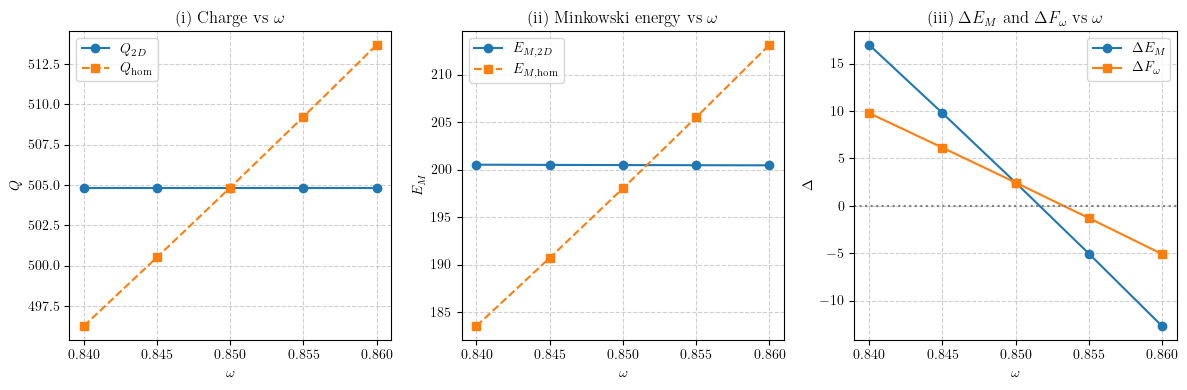

In [ ]:
# Ω Scan summary plots and success/fail summary
import pandas as pd

df_omega = pd.DataFrame(omega_scan_results)
ok = df_omega["status"] == "OK"
n_ok = int(ok.sum())
failed_omega = df_omega.loc[~ok, "omega"].tolist() if not ok.all() else []

print("========== Ω Scan summary ==========")
print(f"  Successful ω points: {n_ok} / {len(omega_scan_results)}")
if failed_omega:
    print(f"  Failed ω (Newton or Q-match): {failed_omega}")
print("")

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
w = df_omega["omega"]
ax1.plot(w, df_omega["Q_2D"], "o-", label=r"$Q_{2D}$")
ax1.plot(w, df_omega["Q_hom"], "s--", label=r"$Q_{\mathrm{hom}}$")
ax1.set_xlabel(r"$\omega$")
ax1.set_ylabel(r"$Q$")
ax1.legend()
ax1.grid(True, ls="--", alpha=0.6)
ax1.set_title(r"(i) Charge vs $\omega$")

ax2.plot(w, df_omega["E_M_2D"], "o-", label=r"$E_{M,2D}$")
ax2.plot(w, df_omega["E_M_hom"], "s--", label=r"$E_{M,\mathrm{hom}}$")
ax2.set_xlabel(r"$\omega$")
ax2.set_ylabel(r"$E_M$")
ax2.legend()
ax2.grid(True, ls="--", alpha=0.6)
ax2.set_title(r"(ii) Minkowski energy vs $\omega$")

ax3.plot(w, df_omega["delta_E_M"], "o-", label=r"$\Delta E_M$")
ax3.plot(w, df_omega["delta_F_omega"], "s-", label=r"$\Delta F_\omega$")
ax3.axhline(0, color="gray", ls=":")
ax3.set_xlabel(r"$\omega$")
ax3.set_ylabel(r"$\Delta$")
ax3.legend()
ax3.grid(True, ls="--", alpha=0.6)
ax3.set_title(r"(iii) $\Delta E_M$ and $\Delta F_\omega$ vs $\omega$")
plt.tight_layout()
plt.show()

## β scan: F^bounce e F_activation vs β

Scan su β decrescente: a ogni β si risolve Newton con ansatz gated (ω = OMEGA fisso), si fa matching su η₀ con la carica omogenea a OMEGA, si calcolano S_E^2D, S_E^hom, F^bounce e F_activation (con E_1d,crit e E_M,hom). Si salvano i dati per plottare F^bounce e F_activation vs β. Alla fine si aggiunge a mano il punto (β=0, F=0).

In [127]:
# Parametri β-scan: OMEGA fisso, Lr, griglia, lista β decrescente
OMEGA_beta = float(OMEGA)  # usa OMEGA del notebook (es. 0.86)
Lr_beta = 5.0
Nr_beta = 60
Ntau_beta = 60
max_newton_iter_beta = 35
d_eta_beta = 0.05
max_bracket_beta = 80
tol_Q_beta = 1e-6

# Griglia β: 20, 15, 10 → 0.5 fino a 4 (step 0.5) → 0.1 fino a 0.5 (step 0.1) → aggiungi 0
beta_high = [20.0, 15.0, 10.0, 9,8,7,6,5]
beta_mid = np.arange(9.0, 5.0, -0.5).tolist()   # 4, 3.5, 3, 2.5, 2, 1.5, 1, 0.5
beta_low = np.arange(4.5, 0.4, -0.1).tolist()  # 0.5, 0.4, 0.3, 0.2, 0.1
beta_grid_scan = beta_high + beta_mid + beta_low

beta_grid_scan = sorted(set(beta_grid_scan), reverse=True)
print("β grid (decrescente, con 0 in coda):", beta_grid_scan[:5], "...", beta_grid_scan[-3:])

β grid (decrescente, con 0 in coda): [20.0, 15.0, 10.0, 9, 8.5] ... [0.7000000000000135, 0.6000000000000139, 0.5000000000000142]


In [ ]:
# β-scan driver: per ogni β (tranne 0) → settings, gated ansatz, Newton, η-scan, salva F^bounce e F_activation
from scipy.optimize import brentq
from Bubble_finder.bounce_1d import solve_bounce
from Bubble_finder.bounce2d import Bubble2DSettings, Bubble2DSolver
from Bubble_finder.ansatz_bubble import AnsatzParams, tau_gate
from Bubble_finder.observables_1d import Q_homogeneous_ball, compute_energy_physical_1d_volume_corrected
from Bubble_finder.observables_2d import homogeneous_energy_2d, homogeneous_E_M_2d
from Bubble_finder.rate_exponent import (
    compute_euclidean_action_full, compute_homogeneous_action, volume_from_grid,
    compute_suppression_exponent_bubble, compute_activation_exponent_bubble, make_V_of_s_from_U,
)
from Q_ball_finder.notebook_utils import resample_complex_field

rho_false_beta, _ = vacua_of_Omega(PHI0, V1, V2, OMEGA_beta)
V_ball_beta = (4.0 / 3.0) * np.pi * Lr_beta**3
Q_target_beta = float(Q_homogeneous_ball(OMEGA_beta, rho_false_beta, Lr_beta))
E_hom_beta = float(homogeneous_energy_2d(OMEGA_beta, rho_false_beta, Lr_beta, U))
E_M_hom_beta = float(homogeneous_E_M_2d(OMEGA_beta, rho_false_beta, Lr_beta, U))
V_of_s_beta = make_V_of_s_from_U(U)
params_gated_beta = AnsatzParams(eps=1.0, k=1, phase=0.0, amp=1.0, tau_gate_frac=0.25, tau_gate_center_frac=1, r_window_frac=0.15)

def solve_at_eta_b(solver, eta, x0, verbose=False):
    solver.settings.eta0 = float(eta)
    solver.eta0 = float(eta)
    sol = solver.solve(x0, verbose=verbose, verbose_success_block=False, store_iteration_history=False)
    return float(sol.Q_tau0.real), sol

def eta_scan_at_beta_b(solver, eta_start, x_seed, Q_target, V_ref, Q_hom_ref, E_hom_ref, d_eta=0.05, max_steps=80, tol_Q=1e-6, verbose=True):
    tol_Q = tol_Q * max(1.0, abs(Q_target))
    eta_cache = {}
    eta_cache_precision = 1e-12
    E_Q_ref = E_hom_ref if (E_hom_ref and abs(E_hom_ref) > 1e-30) else 1.0
    eta_curr = eta_start
    Q_curr, sol_curr = solve_at_eta_b(solver, eta_curr, x_seed, verbose=False)
    x_seed = sol_curr.x.copy()
    E_curr = float(sol_curr.E_tau0)
    ratioQ = (Q_curr / Q_target) if Q_target and abs(Q_target) > 1e-30 else 0.0
    ratioE = (E_curr / E_Q_ref) if E_Q_ref else 0.0
    eta_cache[round(eta_curr / eta_cache_precision) * eta_cache_precision] = (Q_curr, E_curr, ratioQ, ratioE)
    if abs(Q_curr - Q_target) < tol_Q:
        if verbose:
            print(f"[eta-scan] eta* = {eta_curr:.6f}, charge = {Q_curr:.6e}, energy = {E_curr:.6e}, ratioQ = {ratioQ:.6f}, ratioE = {ratioE:.6f}")
        return eta_curr, sol_curr, x_seed, dict(Q=Q_curr, E=E_curr)
    if verbose:
        print(f"[eta-scan] eta = {eta_curr:.6f}, charge = {Q_curr:.6e}, energy = {E_curr:.6e}, target = {Q_target:.6e}, ratioQ = {ratioQ:.6f}")
    eta_prev, Q_prev = eta_curr, Q_curr
    for _ in range(max_steps):
        if Q_curr < Q_target:
            eta_prev, Q_prev = eta_curr, Q_curr
            eta_curr += d_eta
        else:
            eta_prev, Q_prev = eta_curr, Q_curr
            eta_curr -= d_eta
        Q_curr, sol_curr = solve_at_eta_b(solver, eta_curr, x_seed, verbose=False)
        x_seed = sol_curr.x.copy()
        E_curr = float(sol_curr.E_tau0)
        ratioQ = (Q_curr / Q_target) if Q_target and abs(Q_target) > 1e-30 else 0.0
        ratioE = (E_curr / E_Q_ref) if E_Q_ref else 0.0
        eta_cache[round(eta_curr / eta_cache_precision) * eta_cache_precision] = (Q_curr, E_curr, ratioQ, ratioE)
        if verbose:
            print(f"[eta-scan] try eta = {eta_curr:.6f}, charge = {Q_curr:.6e}, energy = {E_curr:.6e}, ratioQ = {ratioQ:.6f}, ratioE = {ratioE:.6f}")
        if (Q_prev - Q_target) * (Q_curr - Q_target) <= 0:
            break
    else:
        raise RuntimeError("eta scan did not cross Q_target within max_steps")
    eta_lo, eta_hi = (eta_curr, eta_prev) if Q_prev < Q_target else (eta_prev, eta_curr)
    state = {"x_seed": x_seed}
    def f_eta(eta_f):
        q, s = solve_at_eta_b(solver, eta_f, state["x_seed"], verbose=False)
        return q - Q_target
    eta_star = float(brentq(f_eta, eta_lo, eta_hi, xtol=1e-10))
    _, sol_final = solve_at_eta_b(solver, eta_star, state["x_seed"], verbose=False)
    Q_final = float(sol_final.Q_tau0.real)
    E_final = float(sol_final.E_tau0)
    if verbose:
        print(f"[eta-scan] eta* = {eta_star:.6f}, charge = {Q_final:.6e}, energy = {E_final:.6e}, ratioQ = {Q_final/Q_target:.6f}")
    return eta_star, sol_final, state["x_seed"], dict(Q=Q_final, E=E_final)

beta_scan_results = []
verbose_beta = True
sol_prev = None
r_prev = None
tau_prev = None
eta_star_prev = 0.0
for idx_b, beta in enumerate(beta_grid_scan):
    rec = {"beta": beta, "F_bounce": np.nan, "F_activation_1d": np.nan, "F_activation_2D": np.nan,
           "eta_star": np.nan, "Q": np.nan, "S_E_2D": np.nan, "S_E_hom": np.nan, "status": "OK"}
    if beta == 0.0:
        rec["F_bounce"] = 0.0
        rec["F_activation_1d"] = 0.0
        rec["F_activation_2D"] = 0.0
        beta_scan_results.append(rec)
        if verbose_beta:
            print(f"[β-scan] β=0 → (0, 0) aggiunto a mano")
        continue
    try:
        settings_b = Bubble2DSettings(
            Nr=Nr_beta, Ntau=Ntau_beta, Lr=Lr_beta, beta=beta,
            omega_ref=OMEGA_beta, rho0=float(rho_false_beta), rho0_bracket=(V1 * 0.8, V2 + 0.2),
            newton_tol=1e-8, newton_max_iter=max_newton_iter_beta, tau_bc="twisted",
        )
        solver_b = Bubble2DSolver(settings_b, U, dU, d2U)
        r_b = np.asarray(solver_b.grid.r).flatten()
        tau_b = np.asarray(solver_b.grid.tau).flatten()
        T_b = beta / 2.0
        r_1d_b, phi_1d_b, _, _, _ = solve_bounce(PHI0, V1, V2, OMEGA_beta, d=3, r0=1e-10, rmax=Lr_beta, max_iter=150, verbose=False)
        r_1d_b = np.asarray(r_1d_b, float)
        phi_1d_b = np.asarray(phi_1d_b, float)
        if sol_prev is not None and r_prev is not None and tau_prev is not None:
            y_res_b = resample_complex_field(sol_prev.y, r_prev, tau_prev, r_b, tau_b, clamp_tau_to_plateau=True)
            ybar_res_b = resample_complex_field(sol_prev.ybar, r_prev, tau_prev, r_b, tau_b, clamp_tau_to_plateau=True)
            x0_b = solver_b.pack(y_res_b, ybar_res_b)
            eta_start_b = eta_star_prev
            if verbose_beta:
                print(f"[β-scan] β={beta:.4f} ansatz da step precedente, eta_start={eta_start_b:.6f}")
        else:
            phi_on_r_b = np.interp(r_b, r_1d_b, phi_1d_b, left=phi_1d_b[0], right=phi_1d_b[-1])
            y_slice_b = r_b * (phi_on_r_b - solver_b.rho0)
            g_tau_b = tau_gate(tau_b, T_b, params_gated_beta.tau_gate_frac, center_frac=params_gated_beta.tau_gate_center_frac)
            y_gated_b = params_gated_beta.amp * np.outer(y_slice_b, g_tau_b).astype(complex)
            ybar_gated_b = y_gated_b.copy()
            x0_b = solver_b.pack(y_gated_b, ybar_gated_b)
            eta_start_b = 0.0
        sol_newt_b = solver_b.solve(x0_b, verbose=verbose_beta, verbose_success_block=False, store_iteration_history=False)
        if not getattr(sol_newt_b, "success", True):
            rec["status"] = "FAIL_NEWTON"
            beta_scan_results.append(rec)
            continue
        x_seed_b = sol_newt_b.x.copy()
        eta_star_b, sol_eta_b, _, dens_b = eta_scan_at_beta_b(
            solver_b, eta_start_b, x_seed_b, Q_target_beta, V_ball_beta, Q_target_beta, E_hom_beta,
            d_eta=d_eta_beta, max_steps=max_bracket_beta, tol_Q=tol_Q_beta, verbose=verbose_beta,
        )
        sol_prev = sol_eta_b
        r_prev = r_b.copy()
        tau_prev = tau_b.copy()
        eta_star_prev = eta_star_b
        rec["eta_star"] = eta_star_b
        rec["Q"] = float(dens_b["Q"])
        V_ball_act = volume_from_grid(solver_b.grid)
        S_E_2D_b = compute_euclidean_action_full(sol_eta_b.y, sol_eta_b.ybar, solver_b.grid, OMEGA_beta, eta_star_b, float(rho_false_beta), V_of_s_beta)
        S_E_hom_b = compute_homogeneous_action(beta, V_ball_act, OMEGA_beta, rho_false_beta, V_of_s_beta)
        rec["S_E_2D"] = S_E_2D_b
        rec["S_E_hom"] = S_E_hom_b
        rec["F_bounce"] = compute_suppression_exponent_bubble(S_E_2D_b, S_E_hom_b, eta_star_b, rec["Q"])
        E_1d_crit_b = float(compute_energy_physical_1d_volume_corrected(
            np.asarray(r_1d_b), np.asarray(phi_1d_b), OMEGA_beta, U,
            r_max_ref=Lr_beta, rho_tail=float(rho_false_beta),
        ))
        obs_b = getattr(sol_eta_b, "observables_ghost", None) or {}
        E_M_2D_b = float(obs_b.get("E_M", sol_eta_b.E_tau0))
        rec["F_activation_1d"] = compute_activation_exponent_bubble(beta, E_1d_crit_b, E_M_hom_beta)
        rec["F_activation_2D"] = compute_activation_exponent_bubble(beta, E_M_2D_b, E_M_hom_beta)
    except Exception as e:
        rec["status"] = "FAIL"
        if verbose_beta:
            print(f"[β-scan] β={beta} exception: {e}")
    beta_scan_results.append(rec)
    if verbose_beta and rec["status"] == "OK":
        print(f"[β-scan] β={beta:.4f}  F_bounce={rec['F_bounce']:.6f}  F_activation_1d={rec['F_activation_1d']:.6f}  F_activation_2D={rec['F_activation_2D']:.6f}")
print("β-scan done. OK:", sum(1 for r in beta_scan_results if r["status"] == "OK"))

[vacua_of_Omega] ω=0.86
  phi_false=1.06805520645  Ω_false=-1.28033738307  dΩ=2.74e-08  (ω²-W)=-1.28e-08  Ω''=1.175e+01
  phi_true =2.09636552077  Ω_true =-4.62080124795  dΩ=-3.58e-07  (ω²-W)=8.54e-08  Ω''=4.208e+01
[Newton-explicit] iter=01, ||F||=5.355e+00, rhoQ=9.859881e-01, rhoE=-4.178139e-01, rho_Q/rho_Q_ref=1.0051, rho_E/rho_E_ref=1.0265
[Newton-explicit] iter=02, ||F||=2.916e+00, rhoQ=9.840687e-01, rhoE=-4.160253e-01, rho_Q/rho_Q_ref=1.0031, rho_E/rho_E_ref=1.0221
[Newton-explicit] iter=03, ||F||=9.586e-01, rhoQ=9.819731e-01, rhoE=-4.130614e-01, rho_Q/rho_Q_ref=1.0010, rho_E/rho_E_ref=1.0148
[Newton-explicit] iter=04, ||F||=4.022e-02, rhoQ=9.818464e-01, rhoE=-4.126775e-01, rho_Q/rho_Q_ref=1.0008, rho_E/rho_E_ref=1.0138
[Newton-explicit] iter=05, ||F||=5.067e-05, rhoQ=9.818486e-01, rhoE=-4.126765e-01, rho_Q/rho_Q_ref=1.0008, rho_E/rho_E_ref=1.0138
[Newton-explicit] iter=06, ||F||=3.033e-10, rhoQ=9.818486e-01, rhoE=-4.126765e-01, rho_Q/rho_Q_ref=1.0008, rho_E/rho_E_ref=1.0138
[eta

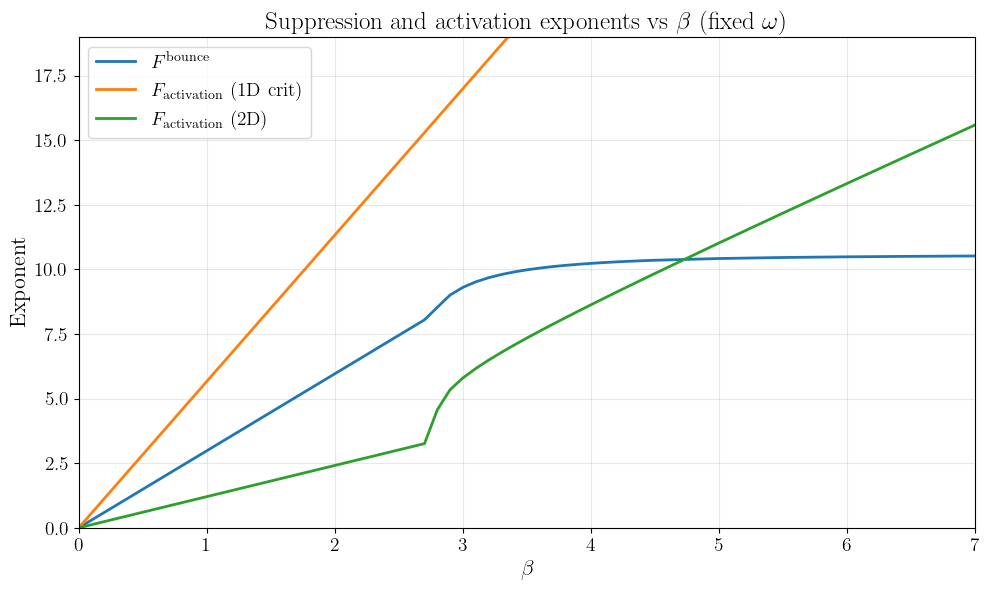

In [ ]:
# Plot F^bounce and F_activation vs β (single figure)
# Use only β > 0 from scan, then prepend (0, 0) so all curves start at the origin
betas = [0] + [r["beta"] for r in beta_scan_results if r["beta"] > 0]
F_bounce_vals = [0] + [r["F_bounce"] for r in beta_scan_results if r["beta"] > 0]
F_act_1d = [0] + [r["F_activation_1d"] for r in beta_scan_results if r["beta"] > 0]
F_act_2D = [0] + [r["F_activation_2D"] for r in beta_scan_results if r["beta"] > 0]
# Sort by β so the curve runs from 0 upward
sorted_tuples = sorted(zip(betas, F_bounce_vals, F_act_1d, F_act_2D))
betas = [t[0] for t in sorted_tuples]
F_bounce_vals = [t[1] for t in sorted_tuples]
F_act_1d = [t[2] for t in sorted_tuples]
F_act_2D = [t[3] for t in sorted_tuples]

fig_b, ax_b = plt.subplots(figsize=(10, 6))
ax_b.plot(betas, F_bounce_vals, "-", color="C0", label=r"$F^{\mathrm{bounce}}$", lw=2)
ax_b.plot(betas, F_act_1d, "-", color="C1", label=r"$F_{\mathrm{activation}}$ (1D crit)", markersize=8, lw=2)
ax_b.plot(betas, F_act_2D, "-", color="C2", label=r"$F_{\mathrm{activation}}$ (2D)", markersize=8, lw=2)
ax_b.set_xlabel(r"$\beta$", fontsize=16)
ax_b.set_ylabel(r"Exponent", fontsize=16)
ax_b.set_title(r"Suppression and activation exponents vs $\beta$ (fixed $\omega$)", fontsize=18)
ax_b.legend(fontsize=14)
ax_b.grid(True, alpha=0.3)
ax_b.set_ylim(0, 19)
ax_b.set_xlim(0, 7)
ax_b.tick_params(axis="both", labelsize=14)
plt.tight_layout()
plt.show()

## Omega scan at fixed β=15, Lr=10

Scan over ω from ω_max×0.95 down to ω_min=0 in steps of 0.05. At each step use the previous step's solution as ansatz and the previous η* as η_start. Store F^bounce (2D), Q, S_E^2D, S_E^hom, η*, E_M^2D, E_M^hom, and charge density Q/V. Then plot F^bounce vs Q/V with vertical lines at ω_max and ω_min and the analytical S₀ (constant).

In [22]:
# Omega-scan parameters: fixed β=15, Lr=10
beta_omega_scan = 20.0
Lr_omega_scan = 7.0
Nr_omega = 100
Ntau_omega = 100
omega_min_scan = 0.0
d_omega_scan = 0.05
max_newton_omega = 35
d_eta_omega = 0.05
max_bracket_omega = 80
tol_Q_omega = 1e-6

# Get omega_max (run the cell that defines has_barrier and computes omega_max first, or set manually)
try:
    omega_max_scan = float(omega_max)
except NameError:
    omega_max_scan = 0.95  # fallback if omega_max not in memory

# Grid: from omega_max*0.95 down to omega_min in steps of 0.05
omega_start = omega_max_scan * 0.95
omega_grid_scan = []
w = omega_start
while w >= omega_min_scan:
    omega_grid_scan.append(w)
    w -= d_omega_scan
    if w < omega_min_scan and abs(w - omega_min_scan) > 1e-10:
        omega_grid_scan.append(omega_min_scan)
omega_grid_scan = np.array(omega_grid_scan)
print(f"Omega scan: β={beta_omega_scan}, Lr={Lr_omega_scan}, ω ∈ [0, {omega_max_scan:.4f}], grid from {omega_grid_scan[0]:.4f} to {omega_grid_scan[-1]:.4f}, {len(omega_grid_scan)} points")

Omega scan: β=20.0, Lr=7.0, ω ∈ [0, 0.9448], grid from 0.8976 to 0.0000, 19 points


In [23]:
# Omega-scan driver: for each ω → solver, ansatz (gated or warm start), Newton, η-scan, save F^bounce and energies
from scipy.optimize import brentq
from Bubble_finder.bounce_1d import solve_bounce
from Bubble_finder.bounce2d import Bubble2DSettings, Bubble2DSolver
from Bubble_finder.ansatz_bubble import AnsatzParams, tau_gate
from Bubble_finder.observables_1d import Q_homogeneous_ball, compute_energy_physical_1d_volume_corrected
from Bubble_finder.observables_2d import homogeneous_energy_2d, homogeneous_E_M_2d
from Bubble_finder.rate_exponent import (
    compute_euclidean_action_full, compute_homogeneous_action, volume_from_grid,
    compute_suppression_exponent_bubble, make_V_of_s_from_U,
)
from Q_ball_finder.notebook_utils import resample_complex_field

def solve_at_eta_om(solver, eta, x0, verbose=False):
    solver.settings.eta0 = float(eta)
    solver.eta0 = float(eta)
    sol = solver.solve(x0, verbose=verbose, verbose_success_block=False, store_iteration_history=False)
    return float(sol.Q_tau0.real), sol

def eta_scan_omega(solver, eta_start, x_seed, Q_target, E_hom_ref, d_eta=0.05, max_steps=80, tol_Q=1e-6, verbose=True):
    tol_Q = tol_Q * max(1.0, abs(Q_target))
    E_Q_ref = E_hom_ref if (E_hom_ref and abs(E_hom_ref) > 1e-30) else 1.0
    eta_curr = eta_start
    Q_curr, sol_curr = solve_at_eta_om(solver, eta_curr, x_seed, verbose=False)
    x_seed = sol_curr.x.copy()
    E_curr = float(sol_curr.E_tau0)
    ratioQ = (Q_curr / Q_target) if Q_target and abs(Q_target) > 1e-30 else 0.0
    if abs(Q_curr - Q_target) < tol_Q:
        if verbose:
            print(f"[eta-scan] eta* = {eta_curr:.6f}, Q = {Q_curr:.6e}, target = {Q_target:.6e}")
        return eta_curr, sol_curr, x_seed
    eta_prev, Q_prev = eta_curr, Q_curr
    for _ in range(max_steps):
        if Q_curr < Q_target:
            eta_prev, Q_prev = eta_curr, Q_curr
            eta_curr += d_eta
        else:
            eta_prev, Q_prev = eta_curr, Q_curr
            eta_curr -= d_eta
        Q_curr, sol_curr = solve_at_eta_om(solver, eta_curr, x_seed, verbose=False)
        x_seed = sol_curr.x.copy()
        ratioQ = (Q_curr / Q_target) if Q_target and abs(Q_target) > 1e-30 else 0.0
        if verbose:
            print(f"[eta-scan] try eta = {eta_curr:.6f}, Q = {Q_curr:.6e}, ratioQ = {ratioQ:.6f}")
        if (Q_prev - Q_target) * (Q_curr - Q_target) <= 0:
            break
    else:
        raise RuntimeError("eta scan did not cross Q_target")
    eta_lo, eta_hi = (eta_curr, eta_prev) if Q_prev < Q_target else (eta_prev, eta_curr)
    def f_eta(eta_f):
        q, s = solve_at_eta_om(solver, eta_f, x_seed, verbose=False)
        return q - Q_target
    eta_star = float(brentq(f_eta, eta_lo, eta_hi, xtol=1e-10))
    _, sol_final = solve_at_eta_om(solver, eta_star, x_seed, verbose=False)
    if verbose:
        print(f"[eta-scan] eta* = {eta_star:.6f}, Q = {float(sol_final.Q_tau0.real):.6e}")
    return eta_star, sol_final, x_seed

V_omega_scan = (4.0 / 3.0) * np.pi * (Lr_omega_scan**3)
params_gated_omega = AnsatzParams(eps=1.0, k=1, phase=0.0, amp=1.0, tau_gate_frac=0.25, tau_gate_center_frac=1, r_window_frac=0.15)

omega_scan_results = []
sol_prev_om = None
r_prev_om = None
tau_prev_om = None
eta_star_prev_om = 0.0
verbose_omega = True

for idx_om, om in enumerate(omega_grid_scan):
    rec = {"omega": om, "F_bounce": np.nan, "Q": np.nan, "rho_Q": np.nan, "S_E_2D": np.nan, "S_E_hom": np.nan,
           "eta_star": np.nan, "E_M_2D": np.nan, "E_M_hom": np.nan, "status": "OK"}
    try:
        rho_false_om, _ = vacua_of_Omega(PHI0, V1, V2, om)
        Q_target_om = float(Q_homogeneous_ball(om, rho_false_om, Lr_omega_scan))
        E_hom_om = float(homogeneous_energy_2d(om, rho_false_om, Lr_omega_scan, U))
        E_M_hom_om = float(homogeneous_E_M_2d(om, rho_false_om, Lr_omega_scan, U))
        settings_om = Bubble2DSettings(
            Nr=Nr_omega, Ntau=Ntau_omega, Lr=Lr_omega_scan, beta=beta_omega_scan,
            omega_ref=om, rho0=float(rho_false_om), rho0_bracket=(V1 * 0.8, V2 + 0.2),
            newton_tol=1e-8, newton_max_iter=max_newton_omega, tau_bc="twisted",
        )
        solver_om = Bubble2DSolver(settings_om, U, dU, d2U)
        r_om = np.asarray(solver_om.grid.r).flatten()
        tau_om = np.asarray(solver_om.grid.tau).flatten()
        T_om = beta_omega_scan / 2.0
        r_1d_om, phi_1d_om, _, _, _ = solve_bounce(PHI0, V1, V2, om, d=3, r0=1e-10, rmax=Lr_omega_scan, max_iter=150, verbose=False)
        r_1d_om = np.asarray(r_1d_om, float)
        phi_1d_om = np.asarray(phi_1d_om, float)
        if sol_prev_om is not None and r_prev_om is not None and tau_prev_om is not None:
            y_res_om = resample_complex_field(sol_prev_om.y, r_prev_om, tau_prev_om, r_om, tau_om, clamp_tau_to_plateau=True)
            ybar_res_om = resample_complex_field(sol_prev_om.ybar, r_prev_om, tau_prev_om, r_om, tau_om, clamp_tau_to_plateau=True)
            x0_om = solver_om.pack(y_res_om, ybar_res_om)
            eta_start_om = eta_star_prev_om
            if verbose_omega:
                print(f"[ω-scan] ω={om:.4f} ansatz from previous step, eta_start={eta_start_om:.6f}")
        else:
            phi_on_r_om = np.interp(r_om, r_1d_om, phi_1d_om, left=phi_1d_om[0], right=phi_1d_om[-1])
            y_slice_om = r_om * (phi_on_r_om - solver_om.rho0)
            g_tau_om = tau_gate(tau_om, T_om, params_gated_omega.tau_gate_frac, center_frac=params_gated_omega.tau_gate_center_frac)
            y_gated_om = params_gated_omega.amp * np.outer(y_slice_om, g_tau_om).astype(complex)
            ybar_gated_om = y_gated_om.copy()
            x0_om = solver_om.pack(y_gated_om, ybar_gated_om)
            eta_start_om = 0.0
        sol_newt_om = solver_om.solve(x0_om, verbose=verbose_omega, verbose_success_block=False, store_iteration_history=False)
        if not getattr(sol_newt_om, "success", True):
            rec["status"] = "FAIL_NEWTON"
            omega_scan_results.append(rec)
            continue
        x_seed_om = sol_newt_om.x.copy()
        eta_star_om, sol_eta_om, _ = eta_scan_omega(
            solver_om, eta_start_om, x_seed_om, Q_target_om, E_hom_om,
            d_eta=d_eta_omega, max_steps=max_bracket_omega, tol_Q=tol_Q_omega, verbose=verbose_omega,
        )
        obs_om = getattr(sol_eta_om, "observables_ghost", None) or {}
        V_of_s_om = make_V_of_s_from_U(U)
        S_E_2D_om = float(compute_euclidean_action_full(sol_eta_om.y, sol_eta_om.ybar, solver_om.grid, om, eta_star_om, float(rho_false_om), V_of_s_om))
        S_E_hom_om = float(compute_homogeneous_action(beta_omega_scan, V_omega_scan, om, float(rho_false_om), V_of_s_om))
        Q_om = float(sol_eta_om.Q_tau0.real)
        rec["F_bounce"] = compute_suppression_exponent_bubble(S_E_2D_om, S_E_hom_om, eta_star_om, Q_om)
        rec["Q"] = Q_om
        rec["rho_Q"] = Q_om / V_omega_scan
        rec["S_E_2D"] = S_E_2D_om
        rec["S_E_hom"] = S_E_hom_om
        rec["eta_star"] = eta_star_om
        rec["E_M_2D"] = float(obs_om.get("E_M", getattr(sol_eta_om, "E_tau0", np.nan)))
        rec["E_M_hom"] = E_M_hom_om
        sol_prev_om = sol_eta_om
        r_prev_om = r_om.copy()
        tau_prev_om = tau_om.copy()
        eta_star_prev_om = eta_star_om
    except Exception as e:
        rec["status"] = "FAIL"
        if verbose_omega:
            print(f"[ω-scan] ω={om:.4f} exception: {e}")
    omega_scan_results.append(rec)
    if verbose_omega and rec["status"] == "OK":
        print(f"[ω-scan] ω={om:.4f}  F_bounce={rec['F_bounce']:.6f}  rho_Q={rec['rho_Q']:.6f}")
print("Omega-scan done. OK:", sum(1 for r in omega_scan_results if r["status"] == "OK"))

[vacua_of_Omega] ω=0.897592
  phi_false=1.08189357326  Ω_false=-1.35664026148  dΩ=-1.45e-08  (ω²-W)=6.72e-09  Ω''=8.824e+00
  phi_true =2.10286154959  Ω_true =-4.91207506087  dΩ=2.65e-07  (ω²-W)=-6.30e-08  Ω''=4.334e+01
[Newton-explicit] iter=01, ||F||=5.765e+00, rhoQ=1.052333e+00, rhoE=-5.329859e-01, rho_Q/rho_Q_ref=1.0016, rho_E/rho_E_ref=1.0067
[Newton-explicit] iter=02, ||F||=5.721e+00, rhoQ=1.050953e+00, rhoE=-5.312375e-01, rho_Q/rho_Q_ref=1.0003, rho_E/rho_E_ref=1.0034
[Newton-explicit] iter=03, ||F||=7.588e-01, rhoQ=1.050869e+00, rhoE=-5.308757e-01, rho_Q/rho_Q_ref=1.0002, rho_E/rho_E_ref=1.0027
[Newton-explicit] iter=04, ||F||=1.330e-02, rhoQ=1.050877e+00, rhoE=-5.308678e-01, rho_Q/rho_Q_ref=1.0002, rho_E/rho_E_ref=1.0027
[Newton-explicit] iter=05, ||F||=1.207e-05, rhoQ=1.050877e+00, rhoE=-5.308671e-01, rho_Q/rho_Q_ref=1.0002, rho_E/rho_E_ref=1.0027
[Newton-explicit] iter=06, ||F||=5.283e-12, rhoQ=1.050877e+00, rhoE=-5.308671e-01, rho_Q/rho_Q_ref=1.0002, rho_E/rho_E_ref=1.0027


[vacua_of_Omega] ω=0
  phi_false=1.00000001839  Ω_false=-0.5  dΩ=1.67e-06  (ω²-W)=-8.35e-07  Ω''=9.636e+05
  phi_true =1.99986461045  Ω_true =-1.50000001833  dΩ=-4.20e-08  (ω²-W)=1.05e-08  Ω''=4.001e+00
[vacua_of_Omega] ω=0.944834
  phi_false=1.11507856643  Ω_false=-1.46111688028  dΩ=-1.37e-09  (ω²-W)=6.13e-10  Ω''=2.897e+00
  phi_true =2.11117002967  Ω_true =-5.29849633642  dΩ=1.86e-07  (ω²-W)=-4.41e-08  Ω''=4.495e+01
[vacua_of_Omega] ω=0
  phi_false=1.00000001839  Ω_false=-0.5  dΩ=1.67e-06  (ω²-W)=-8.35e-07  Ω''=9.636e+05
  phi_true =1.99986461045  Ω_true =-1.50000001833  dΩ=-4.20e-08  (ω²-W)=1.05e-08  Ω''=4.001e+00


/tmp/ipykernel_30781/1801183713.py:26: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  S_E_1d_omega0 = float(4.0 * np.pi * np.trapz(integrand_SE, r_1d_w0))


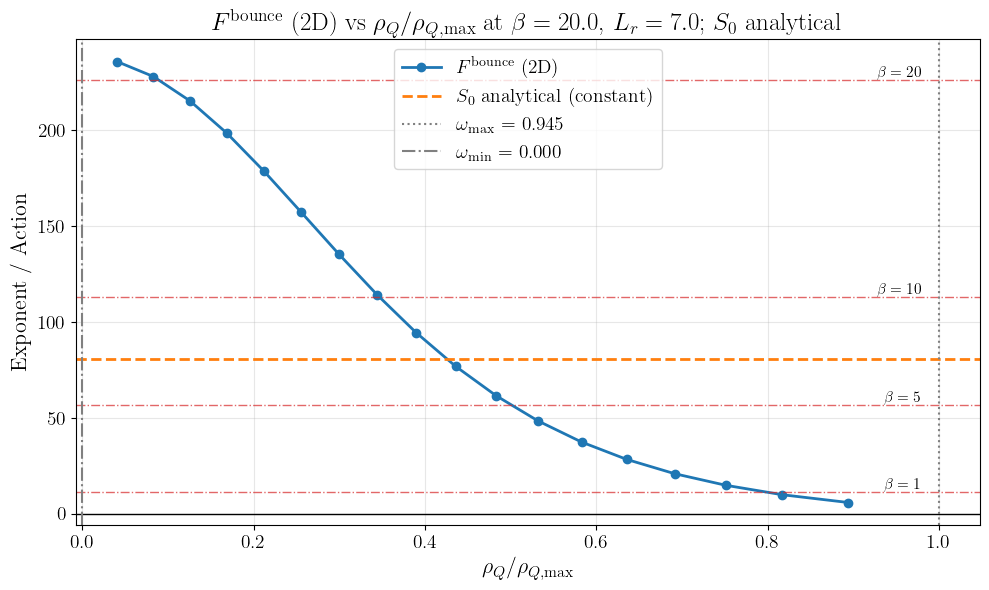

In [26]:
# Plot F^bounce (2D) vs charge density Q/V; vertical lines at ω_max and ω_min; S₀ analytical (constant)
from scipy.special import spence

def S0_analytical_plot(phi0):
    """S₀ = -π²/3 [φ₀ - 1 + Li₂((φ₀-1)/(φ₀-2))]; d=4, Q=0."""
    term = (phi0 - 1) / (phi0 - 2)
    Li2_val = spence(1 - term)
    return -np.pi**2 / 3.0 * (phi0 - 1 + Li2_val)

valid = [r for r in omega_scan_results if r["status"] == "OK"]
rho_Q_vals = [r["rho_Q"] for r in valid]
F_bounce_vals_om = [r["F_bounce"] for r in valid]
omega_vals = [r["omega"] for r in valid]

S0_const = S0_analytical_plot(PHI0)
# S_E of 1D bounce at ω=0: S_E = 4π ∫ r² [ (1/2)(dφ/dr)² + V(φ) ] dr
from Bubble_finder.bounce_1d import solve_bounce
r_1d_w0, phi_1d_w0, _, _, _ = solve_bounce(PHI0, V1, V2, 0.0, d=3, r0=1e-10, rmax=Lr_omega_scan, max_iter=150, verbose=False)
r_1d_w0 = np.asarray(r_1d_w0, float)
phi_1d_w0 = np.asarray(phi_1d_w0, float)
rho_false_w0, _ = vacua_of_Omega(PHI0, V1, V2, 0.0)
V_false_w0 = float(np.asarray(U(np.array([float(rho_false_w0)]))).flat[0])
dphi_dr = np.gradient(phi_1d_w0, r_1d_w0)
V_at_phi = np.asarray(U(phi_1d_w0)).flatten()
integrand_SE = r_1d_w0**2 * (0.5 * dphi_dr**2 + V_at_phi - V_false_w0)
S_E_1d_omega0 = float(4.0 * np.pi * np.trapz(integrand_SE, r_1d_w0))
# ρ_Q at ω_max and ω_min (physical interval) for vertical lines
rho_false_max, _ = vacua_of_Omega(PHI0, V1, V2, omega_max_scan)
rho_false_min, _ = vacua_of_Omega(PHI0, V1, V2, omega_min_scan)
Q_at_omega_max = float(Q_homogeneous_ball(omega_max_scan, rho_false_max, Lr_omega_scan))
Q_at_omega_min = float(Q_homogeneous_ball(omega_min_scan, rho_false_min, Lr_omega_scan))
rho_Q_at_omega_max = Q_at_omega_max / V_omega_scan
rho_Q_at_omega_min = Q_at_omega_min / V_omega_scan
rho_Q_max = rho_Q_at_omega_max  # riferimento fisico: riscalo tutti i punti rispetto a questo
rho_Q_norm = [q / rho_Q_max for q in rho_Q_vals]
rho_Q_at_omega_max_norm = 1.0
rho_Q_at_omega_min_norm = rho_Q_at_omega_min / rho_Q_max

fig_om, ax_om = plt.subplots(figsize=(10, 6))
ax_om.plot(rho_Q_norm, F_bounce_vals_om, "o-", color="C0", label=r"$F^{\mathrm{bounce}}$ (2D)", markersize=6, lw=2)
ax_om.axhline(0, color="black", lw=1)
ax_om.axhline(S0_const, color="C1", ls="--", lw=2, label=rf"$S_0$ analytical (constant)")
for b in [20, 10, 5, 1]:
    ax_om.axhline(b * S_E_1d_omega0, color="C3", ls="-.", lw=1, alpha=0.7)
    ax_om.text(0.98, b * S_E_1d_omega0, rf"$\beta={b}$", ha="right", va="bottom", fontsize=11)
ax_om.axvline(rho_Q_at_omega_max_norm, color="gray", ls=":", lw=1.5, label=rf"$\omega_{{\max}}$ = {omega_max_scan:.3f}")
ax_om.axvline(rho_Q_at_omega_min_norm, color="gray", ls="-.", lw=1.5, label=rf"$\omega_{{\min}}$ = {omega_min_scan:.3f}")
ax_om.set_xlabel(r"$\rho_Q/\rho_{Q,\max}$", fontsize=16)
ax_om.set_ylabel(r"Exponent / Action", fontsize=16)
ax_om.set_title(rf"$F^{{\mathrm{{bounce}}}}$ (2D) vs $\rho_Q/\rho_{{Q,\max}}$ at $\beta={beta_omega_scan}$, $L_r={Lr_omega_scan}$; $S_0$ analytical", fontsize=18)
ax_om.legend(fontsize=14)
ax_om.grid(True, alpha=0.3)
ax_om.tick_params(axis="both", labelsize=14)
plt.tight_layout()
plt.show()